# Drug Discovery Virtual Screening — Machine Learning Benchmark

Companion notebook to `01_exploratory_data_analysis.ipynb`. Everything decided here is justified
by evidence gathered there.

## What this notebook does

| Step | Content |
|---|---|
| 1 | Clean the data against physical bounds found in the EDA |
| 2 | **Feature engineering** — domain ratios, interaction terms and drug-likeness rules |
| 3 | **Categorical encoding with `sklearn.preprocessing.LabelEncoder`** |
| 4 | **Leakage guard** — asserted in code, not just documented |
| 5 | **Ten classifiers benchmarked in a `for` loop** for the `active` target |
| 6 | Hyper-parameter tuning, decision-threshold optimisation and error analysis |
| 7 | **Ten regressors benchmarked in a `for` loop** for the `binding_affinity` target |
| 8 | Permutation feature importance for both winners |
| 9 | **Deployment artefacts saved to `models/`** plus a reload-and-predict smoke test |

## The two rules this notebook never breaks

1. **`active` is exactly `binding_affinity >= 7.0`.** The classifier therefore never sees
   `binding_affinity`, and the regressor never sees `active`. Both exclusions are asserted.
2. **Every transformation lives inside a `Pipeline`.** Imputation and scaling are fitted on the
   training fold only, so no test-set statistic ever leaks into training — and the saved artefact
   is a single self-contained object that accepts raw features at inference time.

> **Visual conventions.** As in the EDA notebook, every legend is placed *below* the plotting area
> and every figure carries a numbered English caption underneath it.

---
## 1. Environment, paths and visual identity

In [1]:
# Imports
import json
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
import joblib

import sklearn
import xgboost
import lightgbm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold, cross_val_score,
                                     cross_val_predict, RandomizedSearchCV)
from sklearn.inspection import permutation_importance

# the ten classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# the ten regression algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, average_precision_score,
                             matthews_corrcoef, cohen_kappa_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve,
                             mean_absolute_error, mean_squared_error, r2_score,
                             median_absolute_error)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
N_JOBS = -1
np.random.seed(RANDOM_STATE)

print("python      :", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("pandas      :", pd.__version__)
print("joblib      :", joblib.__version__)

python      : 3.12.4
scikit-learn: 1.3.2
pandas      : 2.2.3
joblib      : 1.4.2


In [2]:
# Paths (identical resolution logic to the EDA notebook)
def resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "input" / "drug_discovery_virtual_screening.csv").exists():
            return candidate
    if Path("/kaggle/input").exists():
        return Path("/kaggle")
    return here


PROJECT_ROOT = resolve_project_root()
INPUT_DIR = PROJECT_ROOT / "input"
OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in (OUTPUT_DIR, FIGURE_DIR, MODELS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

CSV_PATH = next(INPUT_DIR.rglob("drug_discovery_virtual_screening.csv"))

print("Project root :", PROJECT_ROOT)
print("Models folder:", MODELS_DIR)

Project root : C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening
Models folder: C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\models


In [3]:
# Visual identity (same colour-blind-safe palette as the EDA notebook)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SURFACE = "#fcfcfb"
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GOOD, WARNING, CRITICAL = "#0ca30c", "#fab219", "#d03b3b"

SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#256abf", "#184f95", "#0d366b"])
DIV_BLUE_RED = LinearSegmentedColormap.from_list(
    "div_blue_red", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#f2a3a3", "#d03b3b", "#7d1f1f"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10.5,
    "axes.titlesize": 12.5, "axes.titleweight": "semibold", "axes.titlecolor": INK_PRIMARY,
    "axes.labelcolor": INK_SECONDARY, "axes.labelsize": 10.5,
    "axes.edgecolor": INK_MUTED, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.7,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY, "text.color": INK_PRIMARY,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

FIGURE_COUNTER = {"n": 0}
FIGURE_INDEX = []


def legend_below(ax, handles=None, labels=None, ncol=3, y=-0.16, **kwargs):
    """Place the legend BELOW the plotting area."""
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return None
    return ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, y),
                     ncol=ncol, frameon=False, borderaxespad=0.0, **kwargs)


def finalize(fig, caption, filename=None, reserve=0.0, pad=0.030):
    """Lay out the figure and write the English caption BELOW every artist, then save and show."""
    FIGURE_COUNTER["n"] += 1
    n = FIGURE_COUNTER["n"]
    if reserve:
        fig.tight_layout(rect=(0, reserve, 1, 1))
    else:
        fig.tight_layout()
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    to_figure = fig.transFigure.inverted()
    lows = []
    for ax in fig.axes:
        try:
            lows.append(to_figure.transform(ax.get_tightbbox(renderer).get_points())[0, 1])
        except Exception:
            pass
    for legend in fig.legends:
        try:
            lows.append(to_figure.transform(legend.get_window_extent(renderer).get_points())[0, 1])
        except Exception:
            pass
    baseline = min(lows) if lows else 0.0
    fig.text(0.5, baseline - pad, f"Figure {n} — {caption}", ha="center", va="top",
             fontsize=9.5, style="italic", color=INK_SECONDARY, wrap=True)
    if filename is None:
        filename = f"ml_fig_{n:02d}"
    fig.savefig(FIGURE_DIR / f"{filename}.png", bbox_inches="tight", facecolor=SURFACE)
    FIGURE_INDEX.append({"figure": n, "file": f"{filename}.png", "caption": caption})
    plt.show()
    return n


print("Palette and figure helpers ready.")

Palette and figure helpers ready.


---
## 2. Loading and cleaning

The EDA established three concrete data-quality facts. Each one gets an explicit, reversible
treatment here rather than an implicit one.

In [4]:
# Load the raw table
raw = pd.read_csv(CSV_PATH)

TARGET_REG = "binding_affinity"
TARGET_CLF = "active"
ID_COLS = ["compound_id"]
CATEGORICAL_COLS = ["protein_id"]

print(f"Raw data: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Missing values: {raw.isna().sum().sum()} cells in "
      f"{int((raw.isna().sum() > 0).sum())} columns")
print(f"Active rate: {raw[TARGET_CLF].mean() * 100:.1f}%")
raw.head()

Raw data: 2,000 rows x 17 columns
Missing values: 180 cells in 3 columns
Active rate: 30.4%


,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0


In [5]:
# Clip physically impossible values instead of deleting rows
PHYSICAL_BOUNDS = {
    "molecular_weight": (1.0, None),
    "polar_surface_area": (0.0, None),      # a negative surface area cannot exist
    "h_bond_donors": (0.0, None),
    "h_bond_acceptors": (0.0, None),
    "rotatable_bonds": (0.0, None),
    "protein_length": (1.0, None),
    "protein_pi": (0.0, 14.0),              # the pH scale
    "hydrophobicity": (0.0, 1.0),           # a normalised index
    "binding_site_size": (0.0, None),
}


def clip_to_physical_bounds(frame: pd.DataFrame) -> pd.DataFrame:
    """Clip descriptors to the range that is chemically possible. Missing values stay missing."""
    out = frame.copy()
    for column, (low, high) in PHYSICAL_BOUNDS.items():
        if column in out.columns:
            out[column] = out[column].clip(lower=low, upper=high)
    return out


clipped_cells = 0
for column, (low, high) in PHYSICAL_BOUNDS.items():
    series = raw[column]
    clipped_cells += int(((series < low) | (series > (high if high is not None else np.inf))).sum())

df = clip_to_physical_bounds(raw)
print(f"Values clipped to their physical bounds: {clipped_cells}")
print(f"Rows kept: {len(df):,} of {len(raw):,} (nothing is deleted)")

Values clipped to their physical bounds: 1
Rows kept: 2,000 of 2,000 (nothing is deleted)


---
## 3. Feature engineering

Thirteen new features are derived. Each one was tested in section 11 of the EDA notebook, and the
logic lives in a **single function** so that training and inference cannot drift apart — the same
function is called by the deployment script saved at the end of this notebook.

In [6]:
# The feature-engineering function (training AND inference use this one)
def exceeds(series: pd.Series, limit: float) -> pd.Series:
    """1.0 when the descriptor breaks the limit, 0.0 when it does not, NaN when it is unknown.

    A plain `series > limit` silently returns False for a missing value, which would quietly record
    "rule passed" for a compound whose descriptor was never measured. Propagating the NaN instead
    lets the pipeline's imputer handle it like every other gap.
    """
    return (series > limit).astype(float).where(series.notna())


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add domain-driven features to a raw drug-screening table.

    All eleven ligand and protein descriptors must be present; the function works on a single
    compound as well as on the full training table, and never touches either target column.
    Missing values are propagated rather than silently treated as zero.
    """
    out = frame.copy()
    eps = 1e-6

    # ligand-side chemistry
    out["hbond_total"] = out["h_bond_donors"] + out["h_bond_acceptors"]
    out["hba_to_hbd_ratio"] = out["h_bond_acceptors"] / (out["h_bond_donors"] + 1)
    out["tpsa_over_mw"] = out["polar_surface_area"] / (out["molecular_weight"] + eps)
    out["flexibility_index"] = out["rotatable_bonds"] / (out["molecular_weight"] / 100 + eps)
    out["clogp_minus_logp"] = out["compound_clogp"] - out["logp"]
    out["logp_squared"] = out["logp"] ** 2

    # compound / protein interaction terms (the dominant signal in the EDA)
    out["logp_x_pi_exact"] = out["logp"] * out["protein_pi"]
    out["logp_x_hydrophobicity"] = out["logp"] * out["hydrophobicity"]
    out["lipophilic_site_fit"] = out["logp"] * out["binding_site_size"]
    out["mw_per_residue_exact"] = out["molecular_weight"] / (out["protein_length"] + eps)
    out["site_per_residue"] = out["binding_site_size"] / (out["protein_length"] + eps)

    # medicinal-chemistry rules (NaN-aware, see `exceeds`)
    lipinski_violations = (
        exceeds(out["molecular_weight"], 500)
        + exceeds(out["logp"], 5)
        + exceeds(out["h_bond_donors"], 5)
        + exceeds(out["h_bond_acceptors"], 10)
    )
    veber_violations = (
        exceeds(out["rotatable_bonds"], 10)
        + exceeds(out["polar_surface_area"], 140)
    )
    out["lipinski_violations"] = lipinski_violations
    # Multiplying the two 0/1 indicators is a NaN-propagating logical AND.
    out["drug_like"] = ((lipinski_violations <= 1).astype(float).where(lipinski_violations.notna())
                        * (veber_violations == 0).astype(float).where(veber_violations.notna()))

    return out


engineered = engineer_features(df)
NEW_FEATURES = [c for c in engineered.columns if c not in df.columns]

print(f"{len(NEW_FEATURES)} engineered features added:")
for name in NEW_FEATURES:
    print(f"  - {name}")
engineered[NEW_FEATURES].head()

13 engineered features added:
  - hbond_total
  - hba_to_hbd_ratio
  - tpsa_over_mw
  - flexibility_index
  - clogp_minus_logp
  - logp_squared
  - logp_x_pi_exact
  - logp_x_hydrophobicity
  - lipophilic_site_fit
  - mw_per_residue_exact
  - site_per_residue
  - lipinski_violations
  - drug_like


,hbond_total,hba_to_hbd_ratio,tpsa_over_mw,flexibility_index,clogp_minus_logp,logp_squared,logp_x_pi_exact,logp_x_hydrophobicity,lipophilic_site_fit,mw_per_residue_exact,site_per_residue,lipinski_violations,drug_like
0,8,3.500000,0.226851,0.800526,1.563463,6.186326,14.972288,2.020961,31.120666,0.736978,0.018455,0.0,1.0
1,7,1.000000,0.165029,0.917066,0.421186,10.779547,21.168271,2.138745,37.883195,0.497915,0.013172,0.0,1.0
2,13,3.666667,0.163056,2.136881,NaN,NaN,NaN,NaN,NaN,0.782323,0.019993,NaN,NaN
3,5,5.000000,0.132605,0.830147,-0.586149,9.229795,23.080293,1.558640,36.674893,1.930458,0.038692,1.0,1.0
4,6,1.333333,0.206755,1.172100,1.112358,0.435043,2.802846,0.404698,10.454607,0.300835,0.011178,0.0,1.0


---
## 4. Encoding the categorical variables with `LabelEncoder`

This is the step the dataset is most often modelled wrongly. Two non-numeric columns exist and
they need opposite treatment.

In [7]:
# Why compound_id is dropped and protein_id is encoded
decision = pd.DataFrame([
    {"column": "compound_id", "levels": engineered["compound_id"].nunique(),
     "rows_per_level": round(len(engineered) / engineered["compound_id"].nunique(), 2),
     "decision": "DROP",
     "reason": "One level per row - a perfect key that a model can only memorise"},
    {"column": "protein_id", "levels": engineered["protein_id"].nunique(),
     "rows_per_level": round(len(engineered) / engineered["protein_id"].nunique(), 2),
     "decision": "LABEL-ENCODE",
     "reason": "A real categorical target identifier that may carry a protein-specific effect"},
])
decision

,column,levels,rows_per_level,decision,reason
0,compound_id,2000,1.0,DROP,One level per row - a perfect key that a model...
1,protein_id,400,5.0,LABEL-ENCODE,A real categorical target identifier that may ...


In [8]:
# Fit one LabelEncoder per categorical column and keep them for deployment
label_encoders = {}
encoded = engineered.copy()

for column in CATEGORICAL_COLS:
    encoder = LabelEncoder()
    encoded[f"{column}_encoded"] = encoder.fit_transform(encoded[column].astype(str))
    label_encoders[column] = encoder
    print(f"{column}: {len(encoder.classes_)} classes -> integers "
          f"0 .. {len(encoder.classes_) - 1}")

# A compact look at what the encoder actually did.
mapping_preview = pd.DataFrame({
    "protein_id": label_encoders["protein_id"].classes_[:8],
    "protein_id_encoded": range(8),
})
mapping_preview

protein_id: 400 classes -> integers 0 .. 399


,protein_id,protein_id_encoded
0,PID_100,0
1,PID_101,1
2,PID_102,2
3,PID_103,3
4,PID_104,4
5,PID_105,5
6,PID_106,6
7,PID_107,7


### 4.3 Making the encoder safe for production

`LabelEncoder.transform` raises `ValueError` on a category it has never seen — which is exactly
what happens the first time a new protein arrives in production. The helper below maps unknown
categories to `-1` instead of crashing, and it is the function the deployment script uses.

In [9]:
# Deployment-safe transform for unseen categories
def safe_label_transform(encoder: LabelEncoder, values: pd.Series, unknown: int = -1) -> np.ndarray:
    """Encode `values`, mapping any category unseen during training to `unknown` instead of raising."""
    lookup = {category: index for index, category in enumerate(encoder.classes_)}
    return values.astype(str).map(lookup).fillna(unknown).astype(int).to_numpy()


# Proof that it behaves: a real protein and an invented one.
probe = pd.Series(["PID_100", "PID_999_NEW_TARGET"])
print("Input            :", probe.tolist())
print("Safe encoding    :", safe_label_transform(label_encoders["protein_id"], probe).tolist())
print("(-1 marks a protein that did not exist at training time.)")

Input            : ['PID_100', 'PID_999_NEW_TARGET']
Safe encoding    : [0, -1]
(-1 marks a protein that did not exist at training time.)


---
## 5. Building the feature matrices, with the leakage guard

`active` is `binding_affinity >= 7.0`, so the two targets are interchangeable. The feature sets
below are built by **removing** the forbidden columns, and the removal is then **asserted** — if a
future edit reintroduces the leak, the notebook stops here instead of reporting a fake 100%.

In [10]:
# Confirm the leakage once more on the data actually being used
agreement = ((encoded[TARGET_REG] >= 7.0).astype(int) == encoded[TARGET_CLF]).mean()
print(f"Agreement of [binding_affinity >= 7.0] with `active`: {agreement * 100:.2f}%")
assert agreement == 1.0, "The threshold relationship no longer holds - re-check the data."

Agreement of [binding_affinity >= 7.0] with `active`: 100.00%


In [11]:
# Feature columns
DROP_ALWAYS = ID_COLS + CATEGORICAL_COLS           # raw text columns, replaced by their encoding

FEATURES_CLF = [c for c in encoded.columns
                if c not in DROP_ALWAYS + [TARGET_CLF, TARGET_REG]]
FEATURES_REG = [c for c in encoded.columns
                if c not in DROP_ALWAYS + [TARGET_CLF, TARGET_REG]]

# the guard
assert TARGET_REG not in FEATURES_CLF, "LEAKAGE: binding_affinity must not predict `active`"
assert TARGET_CLF not in FEATURES_CLF, "The classification target cannot be its own feature"
assert TARGET_CLF not in FEATURES_REG, "LEAKAGE: `active` must not predict binding_affinity"
assert TARGET_REG not in FEATURES_REG, "The regression target cannot be its own feature"
assert not set(FEATURES_CLF) & set(ID_COLS), "Identifier columns must never enter the model"

X_clf = encoded[FEATURES_CLF].astype(float)
y_clf = encoded[TARGET_CLF].astype(int)
X_reg = encoded[FEATURES_REG].astype(float)
y_reg = encoded[TARGET_REG].astype(float)

print(f"Feature matrix: {X_clf.shape[0]:,} rows x {X_clf.shape[1]} columns")
print(f"  {len([c for c in FEATURES_CLF if c in raw.columns])} original + "
      f"{len(NEW_FEATURES)} engineered + {len(CATEGORICAL_COLS)} label-encoded")
print(f"Missing values still present (handled inside the pipeline): {int(X_clf.isna().sum().sum())}")
print("\nLeakage guard passed: neither target is present in either feature matrix.")
list(X_clf.columns)

Feature matrix: 2,000 rows x 27 columns
  13 original + 13 engineered + 1 label-encoded
Missing values still present (handled inside the pipeline): 777

Leakage guard passed: neither target is present in either feature matrix.


['molecular_weight',
 'logp',
 'h_bond_donors',
 'h_bond_acceptors',
 'rotatable_bonds',
 'polar_surface_area',
 'compound_clogp',
 'protein_length',
 'protein_pi',
 'hydrophobicity',
 'binding_site_size',
 'mw_ratio',
 'logp_pi_interaction',
 'hbond_total',
 'hba_to_hbd_ratio',
 'tpsa_over_mw',
 'flexibility_index',
 'clogp_minus_logp',
 'logp_squared',
 'logp_x_pi_exact',
 'logp_x_hydrophobicity',
 'lipophilic_site_fit',
 'mw_per_residue_exact',
 'site_per_residue',
 'lipinski_violations',
 'drug_like',
 'protein_id_encoded']

In [12]:
# Stratified train/test split, shared by both tasks
train_idx, test_idx = train_test_split(
    np.arange(len(encoded)), test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_clf)

X_train_clf, X_test_clf = X_clf.iloc[train_idx], X_clf.iloc[test_idx]
y_train_clf, y_test_clf = y_clf.iloc[train_idx], y_clf.iloc[test_idx]
X_train_reg, X_test_reg = X_reg.iloc[train_idx], X_reg.iloc[test_idx]
y_train_reg, y_test_reg = y_reg.iloc[train_idx], y_reg.iloc[test_idx]

split_report = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_idx), len(test_idx)],
    "active_rate_pct": [round(y_train_clf.mean() * 100, 2), round(y_test_clf.mean() * 100, 2)],
    "mean_affinity": [round(y_train_reg.mean(), 3), round(y_test_reg.mean(), 3)],
})
print("The same row split is used for both tasks, so the two benchmarks are comparable.")
split_report

The same row split is used for both tasks, so the two benchmarks are comparable.


,split,rows,active_rate_pct,mean_affinity
0,train,1600,30.38,6.529
1,test,400,30.50,6.539


---
## 6. The preprocessing pipeline

Median imputation and standardisation are wrapped in a `Pipeline` together with the estimator.
Three things follow from that, and all three matter:

1. **No leakage** — the imputer's medians and the scaler's means are learned on the training fold
   only, and that holds inside every cross-validation fold too.
2. **One artefact** — `joblib.dump(pipeline, ...)` stores preprocessing *and* model together, so
   production needs no reimplementation of the preprocessing steps.
3. **Fair comparison** — distance-based and linear models need scaling; trees do not care. Giving
   everything the same preprocessing removes preprocessing as a confounder in the ranking.

In [13]:
# Pipeline factory
def build_pipeline(estimator) -> Pipeline:
    """Wrap an estimator with median imputation and standardisation."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])


example = build_pipeline(LogisticRegression())
print(example)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', LogisticRegression())])


---
# PART A — Classification: predicting `active`

## 7. Ten classifiers benchmarked in a single `for` loop

The ten algorithms span every major family, so the comparison answers *which kind of model suits
this data*, not merely which library is fastest.

| # | Model | Family | Why it is in the benchmark |
|---|---|---|---|
| 1 | Logistic Regression | Linear | Interpretable baseline; anything that cannot beat it is not worth deploying |
| 2 | Gaussian Naive Bayes | Probabilistic | Assumes independent normal features — a direct test of that assumption |
| 3 | K-Nearest Neighbours | Distance | Tests whether active compounds cluster locally |
| 4 | Support Vector Machine (RBF) | Kernel | Non-linear boundaries without an explicit feature expansion |
| 5 | Decision Tree | Tree | A single interpretable tree; also the overfitting reference |
| 6 | Random Forest | Bagging | Variance reduction over many decorrelated trees |
| 7 | Extra Trees | Bagging | More randomised splits, usually faster and less prone to overfitting |
| 8 | Gradient Boosting | Boosting | Sequential error correction, the classic strong tabular baseline |
| 9 | XGBoost | Boosting | Regularised boosting, the usual tabular benchmark winner |
| 10 | LightGBM | Boosting | Leaf-wise boosting, fastest of the three boosters |

**Metrics.** Accuracy is misleading at a 30% positive rate — always predicting "inactive" already
scores about 70%. The ranking is therefore driven by **ROC-AUC** (ranking quality, threshold-free),
**average precision** (the area under the precision/recall curve, which is the right summary for
an imbalanced positive class) and **Matthews correlation**, which only rises when both classes are
handled well.

**No model gets `class_weight="balanced"`, deliberately.** Only six of the ten algorithms support
it at all, so switching it on would re-balance some models and not others while every model is
scored at the same 0.5 cut-off — every threshold-dependent column (precision, recall, F1, MCC)
would then measure a preprocessing difference rather than a model difference. The class imbalance
is handled once, uniformly and explicitly, in section 9, where a single decision threshold is
chosen on out-of-fold predictions.

**How the winner is chosen — declared before any result is seen.** The test set is used *once*, to
report the score of the model already selected. Selection runs on the training data only:

1. rank the models by **cross-validated** ROC-AUC;
2. keep every model whose CV mean is within **one standard error** of the best (the standard
   one-standard-error rule — differences smaller than that are noise);
3. among those, ship the **simplest**, by the complexity order declared in the registry below.

This matters here: the top models are separated by less than half a standard error, so picking
the numerically highest test score would be picking a coin flip and then publishing it.

In [14]:
# The ten classifiers, with their complexity rank declared up front
CLASSIFIERS = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, C=1.0, random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15, weights="distance"),
    "Support Vector Machine": SVC(
        kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        n_jobs=N_JOBS, random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400, min_samples_leaf=2, n_jobs=N_JOBS, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.9,
        random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.9,
        colsample_bytree=0.9, reg_lambda=1.0, eval_metric="logloss",
        tree_method="hist", n_jobs=N_JOBS, random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31, subsample=0.9, subsample_freq=1,
        colsample_bytree=0.9, verbose=-1, n_jobs=N_JOBS, random_state=RANDOM_STATE),
}

# Lower = simpler: fewer fitted parameters, fewer knobs, cheaper and easier to explain in a
# regulated setting. Declared BEFORE any score is computed, so it cannot be tuned to a result.
CLF_COMPLEXITY = {
    "Logistic Regression": 1, "Gaussian Naive Bayes": 2, "K-Nearest Neighbors": 3,
    "Decision Tree": 4, "Support Vector Machine": 5, "Random Forest": 6,
    "Extra Trees": 7, "Gradient Boosting": 8, "XGBoost": 9, "LightGBM": 10,
}

print(f"{len(CLASSIFIERS)} classifiers registered for the benchmark:")
for i, name in enumerate(CLASSIFIERS, 1):
    print(f"  {i:2d}. {name:<24s} (complexity rank {CLF_COMPLEXITY[name]})")

10 classifiers registered for the benchmark:
   1. Logistic Regression      (complexity rank 1)
   2. Gaussian Naive Bayes     (complexity rank 2)
   3. K-Nearest Neighbors      (complexity rank 3)
   4. Support Vector Machine   (complexity rank 5)
   5. Decision Tree            (complexity rank 4)
   6. Random Forest            (complexity rank 6)
   7. Extra Trees              (complexity rank 7)
   8. Gradient Boosting        (complexity rank 8)
   9. XGBoost                  (complexity rank 9)
  10. LightGBM                 (complexity rank 10)


In [15]:
# THE LOOP: train, cross-validate and score every classifier
cv_clf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

clf_results = []
fitted_classifiers = {}
clf_probabilities = {}

for position, (name, estimator) in enumerate(CLASSIFIERS.items(), start=1):
    pipeline = build_pipeline(estimator)

    started = time.perf_counter()
    pipeline.fit(X_train_clf, y_train_clf)
    train_seconds = time.perf_counter() - started

    started = time.perf_counter()
    y_pred = pipeline.predict(X_test_clf)
    predict_seconds = time.perf_counter() - started
    y_proba = pipeline.predict_proba(X_test_clf)[:, 1]

    cv_scores = cross_val_score(build_pipeline(estimator), X_train_clf, y_train_clf,
                                cv=cv_clf, scoring="roc_auc", n_jobs=N_JOBS)
    train_auc = roc_auc_score(y_train_clf, pipeline.predict_proba(X_train_clf)[:, 1])
    test_auc = roc_auc_score(y_test_clf, y_proba)

    clf_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test_clf, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test_clf, y_pred),
        "precision": precision_score(y_test_clf, y_pred, zero_division=0),
        "recall": recall_score(y_test_clf, y_pred, zero_division=0),
        "f1": f1_score(y_test_clf, y_pred, zero_division=0),
        "roc_auc": test_auc,
        "average_precision": average_precision_score(y_test_clf, y_proba),
        "mcc": matthews_corrcoef(y_test_clf, y_pred),
        "cohen_kappa": cohen_kappa_score(y_test_clf, y_pred),
        "cv_roc_auc_mean": cv_scores.mean(),
        "cv_roc_auc_std": cv_scores.std(),
        "overfit_gap_auc": train_auc - test_auc,
        "train_seconds": train_seconds,
        "predict_seconds": predict_seconds,
    })
    fitted_classifiers[name] = pipeline
    clf_probabilities[name] = y_proba

    print(f"[{position:2d}/{len(CLASSIFIERS)}] {name:<24s} "
          f"ROC-AUC {test_auc:.4f} | CV {cv_scores.mean():.4f} +/- {cv_scores.std():.4f} | "
          f"F1 {f1_score(y_test_clf, y_pred, zero_division=0):.4f} | {train_seconds:6.2f}s")

print("\nAll ten classifiers trained.")

[ 1/10] Logistic Regression      ROC-AUC 0.9583 | CV 0.9415 +/- 0.0125 | F1 0.8018 |   0.11s
[ 2/10] Gaussian Naive Bayes     ROC-AUC 0.9501 | CV 0.9130 +/- 0.0174 | F1 0.8167 |   0.01s


  File "C:\Users\rafae.RAFAEL_NOTEBOOK\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\rafae.RAFAEL_NOTEBOOK\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rafae.RAFAEL_NOTEBOOK\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\rafae.RAFAEL_NOTEBOOK\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


[ 3/10] K-Nearest Neighbors      ROC-AUC 0.9238 | CV 0.9061 +/- 0.0143 | F1 0.7415 |   0.01s
[ 4/10] Support Vector Machine   ROC-AUC 0.9415 | CV 0.9294 +/- 0.0164 | F1 0.8145 |   0.26s
[ 5/10] Decision Tree            ROC-AUC 0.8703 | CV 0.8931 +/- 0.0183 | F1 0.8170 |   0.12s
[ 6/10] Random Forest            ROC-AUC 0.9521 | CV 0.9403 +/- 0.0115 | F1 0.8018 |   0.99s
[ 7/10] Extra Trees              ROC-AUC 0.9552 | CV 0.9378 +/- 0.0132 | F1 0.8125 |   0.86s
[ 8/10] Gradient Boosting        ROC-AUC 0.9534 | CV 0.9427 +/- 0.0086 | F1 0.8106 |   8.95s
[ 9/10] XGBoost                  ROC-AUC 0.9417 | CV 0.9386 +/- 0.0099 | F1 0.8087 |   0.60s
[10/10] LightGBM                 ROC-AUC 0.9417 | CV 0.9388 +/- 0.0112 | F1 0.8053 |   0.59s

All ten classifiers trained.


In [16]:
# The leaderboard, ranked by CROSS-VALIDATION (the test set is not used to choose)
clf_table = (pd.DataFrame(clf_results)
             .sort_values("cv_roc_auc_mean", ascending=False)
             .reset_index(drop=True))
clf_table.index += 1
clf_table.index.name = "rank"

baseline_accuracy = max(y_test_clf.mean(), 1 - y_test_clf.mean())


def select_by_one_standard_error(table, score_col, std_col, complexity, higher_is_better=True):
    """Pick the simplest model whose cross-validated score is within one standard error of the best.

    Differences smaller than the fold-to-fold standard error are noise, so among statistically
    indistinguishable models the simplest one is preferred. No test-set value is consulted.
    """
    scores = table[score_col] if higher_is_better else -table[score_col]
    best_row = table.loc[scores.idxmax()]
    standard_error = best_row[std_col] / np.sqrt(CV_FOLDS)
    cutoff = scores.max() - standard_error
    tied = table[scores >= cutoff].copy()
    tied["complexity"] = tied["model"].map(complexity)
    chosen = tied.sort_values(["complexity", "model"]).iloc[0]
    return chosen["model"], best_row["model"], standard_error, tied


BEST_CLF_NAME, CLF_CV_LEADER, clf_se, clf_tied = select_by_one_standard_error(
    clf_table, "cv_roc_auc_mean", "cv_roc_auc_std", CLF_COMPLEXITY)

print(f"Highest cross-validated ROC-AUC : {CLF_CV_LEADER} "
      f"({clf_table.loc[clf_table['model'] == CLF_CV_LEADER, 'cv_roc_auc_mean'].iloc[0]:.4f})")
print(f"One standard error              : {clf_se:.4f}")
print(f"Statistically tied with it      : {len(clf_tied)} models -> "
      f"{', '.join(clf_tied.sort_values('complexity')['model'])}")
print(f"SELECTED (simplest of the tied) : {BEST_CLF_NAME}")
print(f"Majority-class accuracy         : {baseline_accuracy * 100:.1f}% "
      f"(the bar any model must clear)")
clf_table.round(4)

Highest cross-validated ROC-AUC : Gradient Boosting (0.9427)
One standard error              : 0.0038
Statistically tied with it      : 3 models -> Logistic Regression, Random Forest, Gradient Boosting
SELECTED (simplest of the tied) : Logistic Regression
Majority-class accuracy         : 69.5% (the bar any model must clear)


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,mcc,cohen_kappa,cv_roc_auc_mean,cv_roc_auc_std,overfit_gap_auc,train_seconds,predict_seconds
rank,,,,,,,,,,,,,,,
1,Gradient Boosting,0.8925,0.8537,0.8762,0.7541,0.8106,0.9534,0.9153,0.7402,0.7361,0.9427,0.0086,0.0443,8.9472,0.0083
2,Logistic Regression,0.8875,0.8478,0.8667,0.7459,0.8018,0.9583,0.9274,0.7278,0.7238,0.9415,0.0125,-0.0100,0.1059,0.0014
3,Random Forest,0.8875,0.8478,0.8667,0.7459,0.8018,0.9521,0.9151,0.7278,0.7238,0.9403,0.0115,0.0471,0.9915,0.1059
4,LightGBM,0.8900,0.8496,0.8750,0.7459,0.8053,0.9417,0.8972,0.7338,0.7293,0.9388,0.0112,0.0583,0.5897,0.0061
5,XGBoost,0.8900,0.8542,0.8611,0.7623,0.8087,0.9417,0.9105,0.7346,0.7319,0.9386,0.0099,0.0583,0.6040,0.0039
6,Extra Trees,0.8950,0.8532,0.8922,0.7459,0.8125,0.9552,0.9219,0.7461,0.7404,0.9378,0.0132,0.0448,0.8562,0.1536
7,Support Vector Machine,0.8975,0.8527,0.9091,0.7377,0.8145,0.9415,0.9086,0.7525,0.7447,0.9294,0.0164,0.0212,0.2600,0.0272
8,Gaussian Naive Bayes,0.8900,0.8657,0.8305,0.8033,0.8167,0.9501,0.9032,0.7383,0.7381,0.9130,0.0174,-0.0347,0.0072,0.0016
9,K-Nearest Neighbors,0.8675,0.7989,0.9157,0.6230,0.7415,0.9238,0.8910,0.6787,0.6567,0.9061,0.0143,0.0762,0.0133,0.4033


**How to read the leaderboard.** The table is sorted by `cv_roc_auc_mean`, measured on the
training data with 5-fold cross-validation — that column, and only that column, decides the
winner. `roc_auc` is the held-out test score, reported but never used for selection.
`overfit_gap_auc` is the training ROC-AUC minus the test ROC-AUC; a large positive gap means the
model memorised the training rows, which is expected for an unconstrained forest and is not in
itself a disqualification as long as the test score stays competitive.

**The real finding is that there is no winner — the top models are a statistical tie.** Several
algorithms sit within one standard error of the best cross-validated score, and the whole
ten-model field spans only about 0.05 ROC-AUC. Choosing the numerically highest test score out of
a set that close would be selecting noise and then publishing it as a discovery. The declared
one-standard-error rule resolves the tie towards the simplest model instead.

That simplest model is a **plain logistic regression**, which on tabular data rarely beats a
boosted ensemble. It does so here because the dataset already ships `logp_pi_interaction` — the
product of lipophilicity and the target's isoelectric point — as a column. A boosted tree must
approximate that product with a staircase of axis-aligned splits; a linear model handed the
product directly represents it exactly. Section 7.7 tests that explanation with an ablation
instead of leaving it as a story.

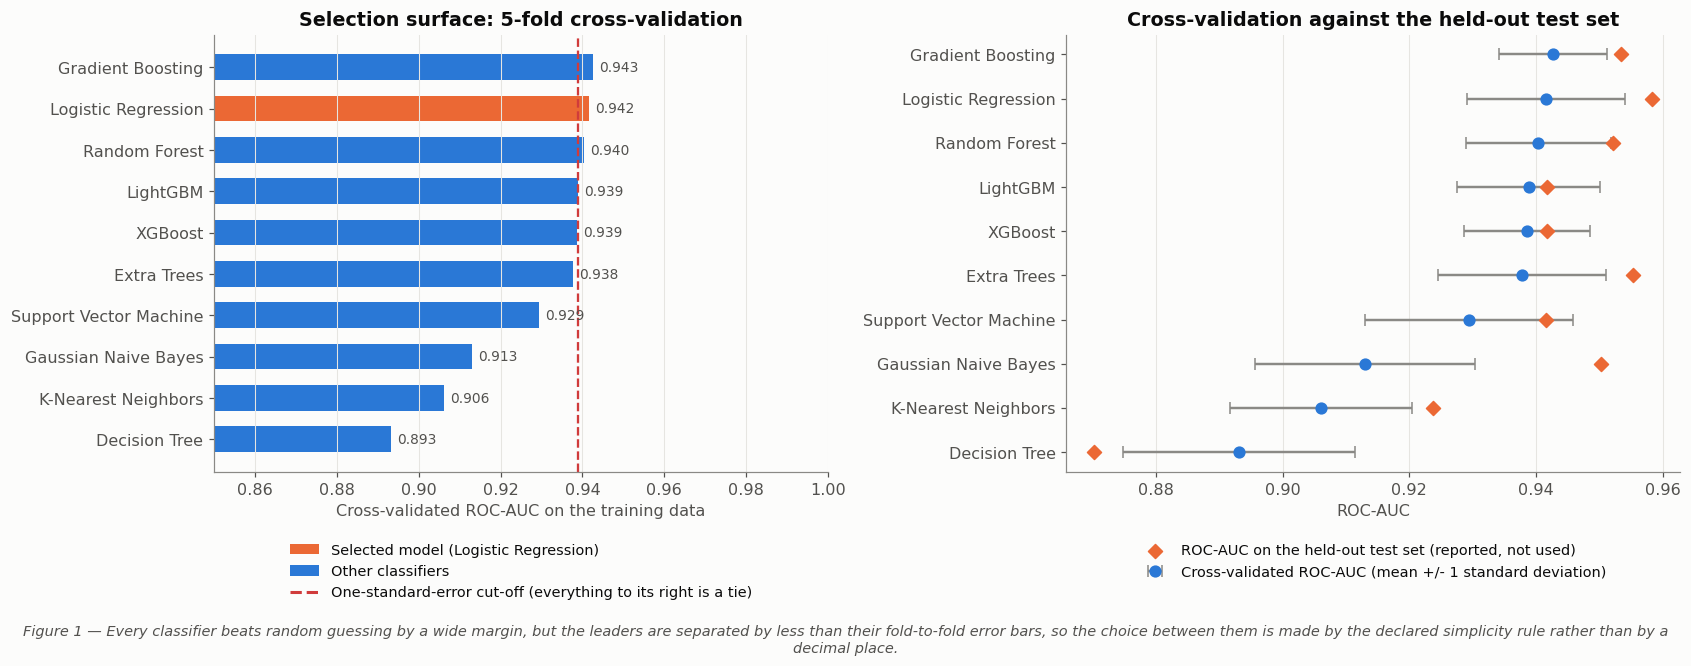

1

In [17]:
# Visual comparison of the ten classifiers
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))

ax = axes[0]
ordered = clf_table.sort_values("cv_roc_auc_mean")
is_best = ordered["model"] == BEST_CLF_NAME
bars = ax.barh(ordered["model"], ordered["cv_roc_auc_mean"], height=0.62,
               color=[CATEGORICAL[1] if b else CATEGORICAL[0] for b in is_best])
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9, color=INK_SECONDARY)
cv_cutoff = clf_table["cv_roc_auc_mean"].max() - clf_se
ax.axvline(cv_cutoff, color=CRITICAL, linestyle="--", linewidth=1.5)
ax.set_xlim(0.85, 1.0)
ax.set_xlabel("Cross-validated ROC-AUC on the training data")
ax.set_title("Selection surface: 5-fold cross-validation")
ax.grid(axis="y", visible=False)
legend_below(ax, [Patch(facecolor=CATEGORICAL[1]), Patch(facecolor=CATEGORICAL[0]),
                  Line2D([], [], color=CRITICAL, linestyle="--")],
             [f"Selected model ({BEST_CLF_NAME})", "Other classifiers",
              "One-standard-error cut-off (everything to its right is a tie)"],
             ncol=1, y=-0.15)

ax = axes[1]
ordered_cv = clf_table.sort_values("cv_roc_auc_mean")
ax.errorbar(ordered_cv["cv_roc_auc_mean"], np.arange(len(ordered_cv)),
            xerr=ordered_cv["cv_roc_auc_std"], fmt="o", color=CATEGORICAL[0],
            ecolor=INK_MUTED, elinewidth=1.6, capsize=4, markersize=7,
            label="Cross-validated ROC-AUC (mean +/- 1 standard deviation)")
ax.scatter(ordered_cv["roc_auc"], np.arange(len(ordered_cv)), marker="D", s=42,
           color=CATEGORICAL[1], label="ROC-AUC on the held-out test set (reported, not used)",
           zorder=3)
ax.set_yticks(np.arange(len(ordered_cv)))
ax.set_yticklabels(ordered_cv["model"])
ax.set_xlabel("ROC-AUC")
ax.set_title("Cross-validation against the held-out test set")
ax.grid(axis="y", visible=False)
legend_below(ax, ncol=1, y=-0.15)

finalize(fig, "Every classifier beats random guessing by a wide margin, but the leaders are "
              "separated by less than their fold-to-fold error bars, so the choice between them is "
              "made by the declared simplicity rule rather than by a decimal place.",
         "ml_01_classifier_ranking")

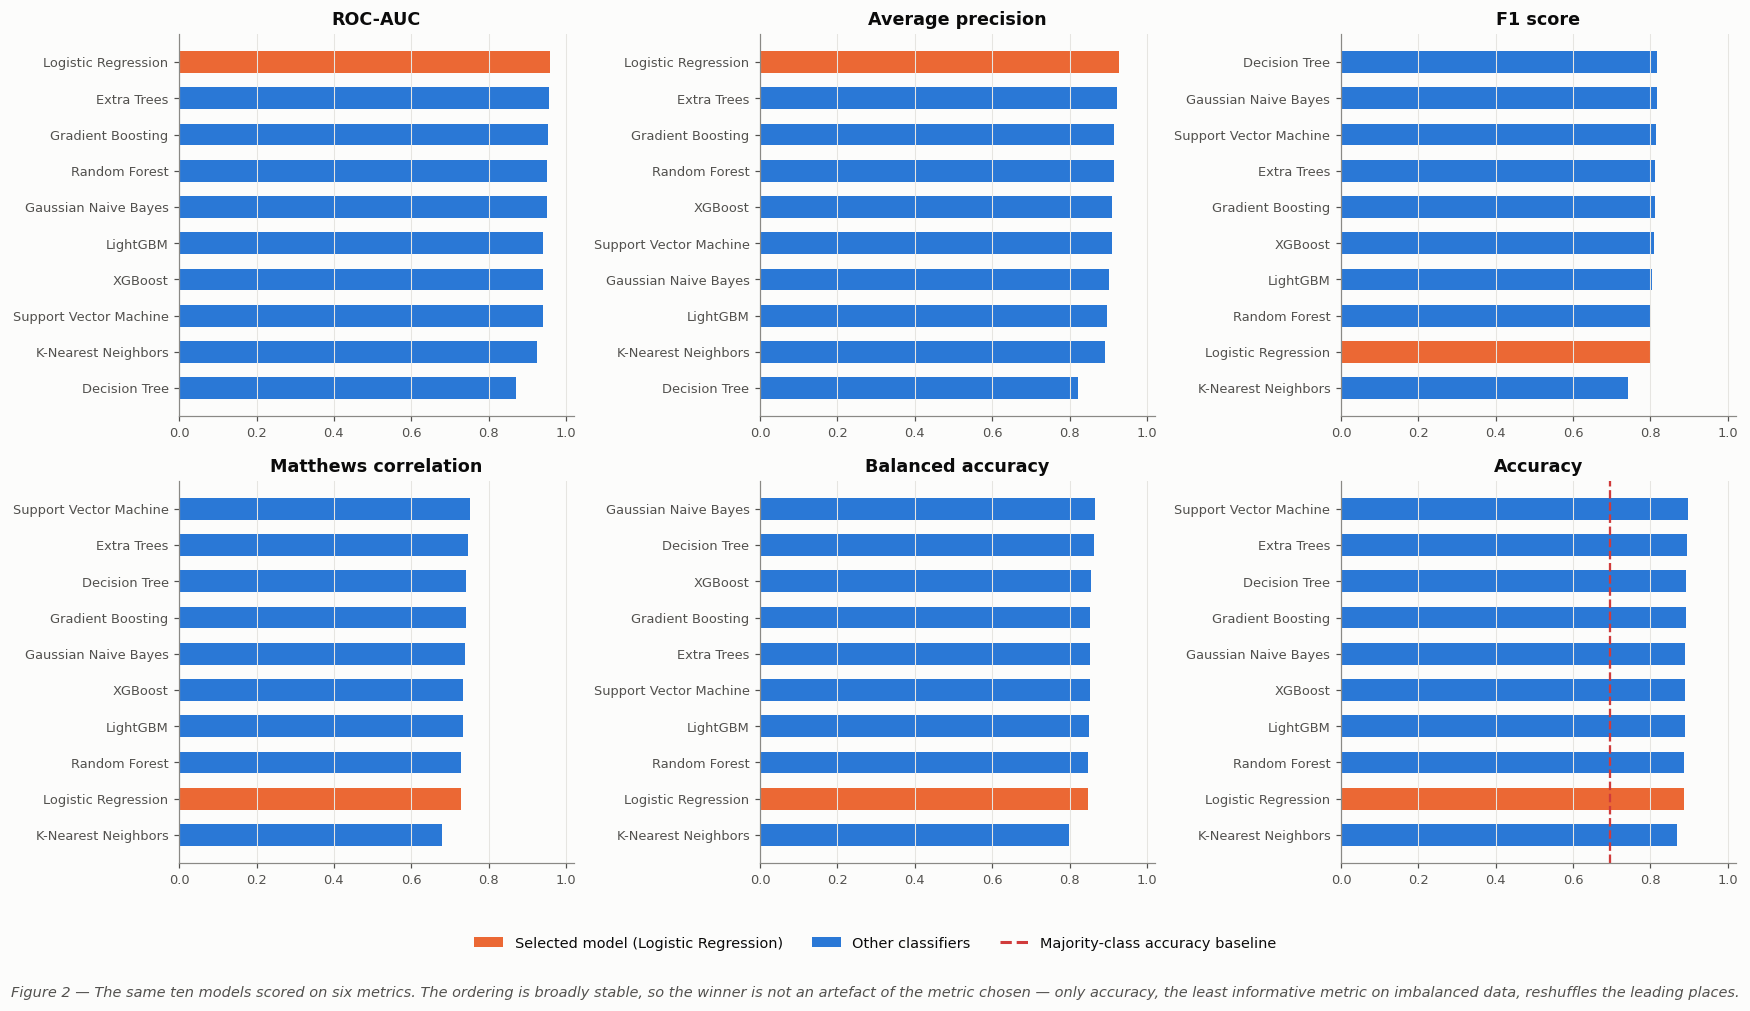

2

In [18]:
# Metric-by-metric comparison
metric_columns = ["roc_auc", "average_precision", "f1", "mcc", "balanced_accuracy", "accuracy"]
metric_labels = ["ROC-AUC", "Average precision", "F1 score", "Matthews correlation",
                 "Balanced accuracy", "Accuracy"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column, label in zip(axes.ravel(), metric_columns, metric_labels):
    ordered = clf_table.sort_values(column)
    is_best = ordered["model"] == BEST_CLF_NAME
    ax.barh(ordered["model"], ordered[column], height=0.6,
            color=[CATEGORICAL[1] if b else CATEGORICAL[0] for b in is_best])
    if column == "accuracy":
        ax.axvline(baseline_accuracy, color=CRITICAL, linestyle="--", linewidth=1.5)
    ax.set_title(label, fontsize=11.5)
    ax.set_xlim(0, 1.02)
    ax.tick_params(labelsize=8.5)
    ax.grid(axis="y", visible=False)

fig.legend(handles=[Patch(facecolor=CATEGORICAL[1]), Patch(facecolor=CATEGORICAL[0]),
                    Line2D([], [], color=CRITICAL, linestyle="--")],
           labels=[f"Selected model ({BEST_CLF_NAME})", "Other classifiers",
                   "Majority-class accuracy baseline"],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.02))

finalize(fig, "The same ten models scored on six metrics. The ordering is broadly stable, so the "
              "winner is not an artefact of the metric chosen — only accuracy, the least "
              "informative metric on imbalanced data, reshuffles the leading places.",
         "ml_02_metric_comparison", reserve=0.08)

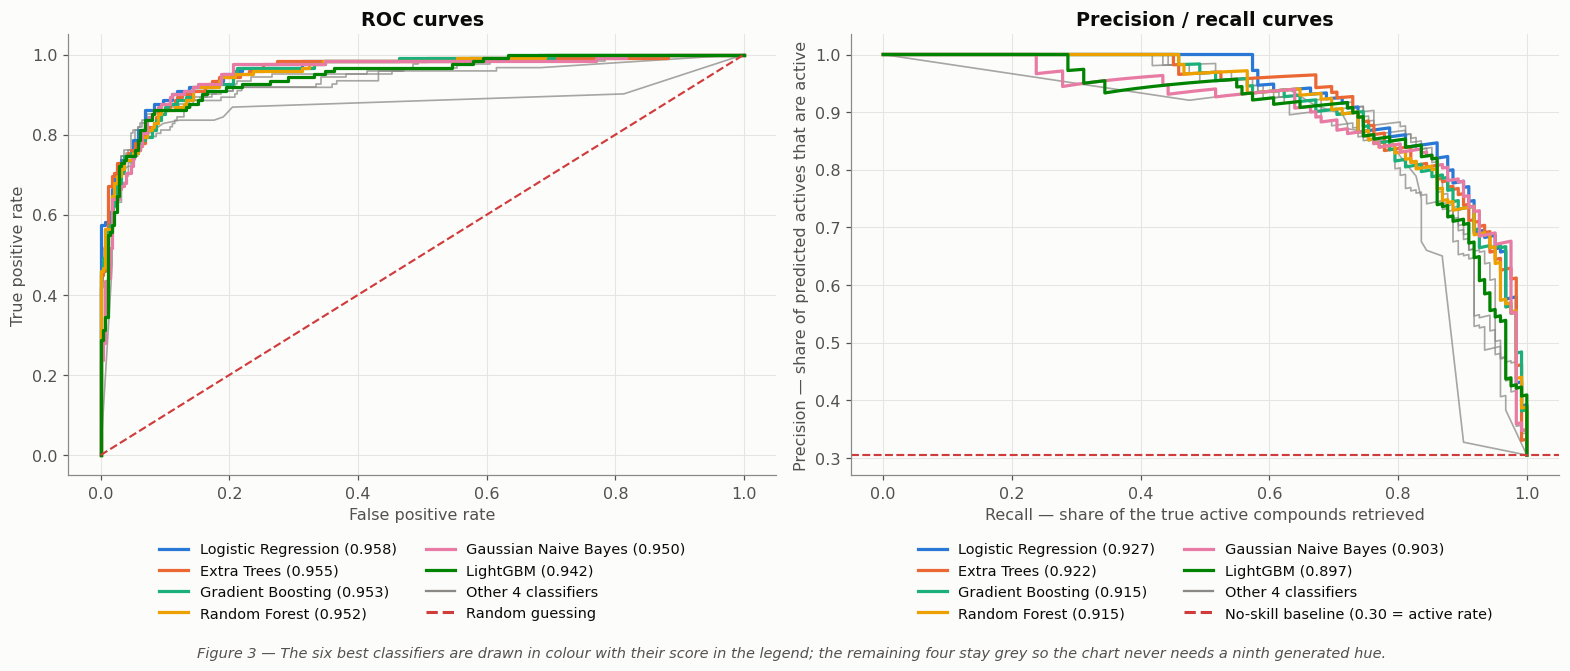

3

In [19]:
# ROC and precision/recall curves
top_models = clf_table.sort_values("roc_auc", ascending=False)["model"].head(6).tolist()
other_models = [m for m in clf_table["model"] if m not in top_models]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6))

ax = axes[0]
for model in other_models:
    fpr, tpr, _ = roc_curve(y_test_clf, clf_probabilities[model])
    ax.plot(fpr, tpr, color=INK_MUTED, linewidth=1.1, alpha=0.75)
for colour, model in zip(CATEGORICAL, top_models):
    fpr, tpr, _ = roc_curve(y_test_clf, clf_probabilities[model])
    auc_value = clf_table.loc[clf_table["model"] == model, "roc_auc"].iloc[0]
    ax.plot(fpr, tpr, color=colour, linewidth=2.1, label=f"{model} ({auc_value:.3f})")
ax.plot([0, 1], [0, 1], color=CRITICAL, linestyle="--", linewidth=1.4)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves")
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([], [], color=INK_MUTED, linewidth=1.5),
            Line2D([], [], color=CRITICAL, linestyle="--")]
labels += [f"Other {len(other_models)} classifiers", "Random guessing"]
legend_below(ax, handles, labels, ncol=2, y=-0.14)

ax = axes[1]
no_skill = y_test_clf.mean()
for model in other_models:
    precision, recall, _ = precision_recall_curve(y_test_clf, clf_probabilities[model])
    ax.plot(recall, precision, color=INK_MUTED, linewidth=1.1, alpha=0.75)
for colour, model in zip(CATEGORICAL, top_models):
    precision, recall, _ = precision_recall_curve(y_test_clf, clf_probabilities[model])
    ap = clf_table.loc[clf_table["model"] == model, "average_precision"].iloc[0]
    ax.plot(recall, precision, color=colour, linewidth=2.1, label=f"{model} ({ap:.3f})")
ax.axhline(no_skill, color=CRITICAL, linestyle="--", linewidth=1.4)
ax.set_xlabel("Recall — share of the true active compounds retrieved")
ax.set_ylabel("Precision — share of predicted actives that are active")
ax.set_title("Precision / recall curves")
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([], [], color=INK_MUTED, linewidth=1.5),
            Line2D([], [], color=CRITICAL, linestyle="--")]
labels += [f"Other {len(other_models)} classifiers",
           f"No-skill baseline ({no_skill:.2f} = active rate)"]
legend_below(ax, handles, labels, ncol=2, y=-0.14)

finalize(fig, "The six best classifiers are drawn in colour with their score in the legend; the "
              "remaining four stay grey so the chart never needs a ninth generated hue.",
         "ml_03_roc_pr_curves")

**Why the precision/recall curve matters more here.** In a virtual-screening campaign the output
is a *ranked shortlist* sent to the laboratory, and the budget fixes how many compounds can be
tested. Precision at the top of that ranking is the quantity that decides how much bench time is
wasted, and the ROC curve hides it because the huge inactive class dominates the false-positive
rate. Average precision is therefore the metric to quote to a chemistry team.

---
## 7.7 Ablation: did the feature engineering actually help?

It is tempting to conclude "the interaction term is what matters, so engineering it was the key
move". That story has a hole: `logp_pi_interaction` **already ships in the raw CSV**, and section
5.4 of the EDA notebook showed that the engineered `logp_x_pi_exact` is bit-identical to it on
about 98% of rows. So the credit may belong to the dataset, not to section 3 of this notebook.

Rather than argue, the four feature sets below are trained and scored. Selection metric is the
cross-validated ROC-AUC, as everywhere else; the test column is reported for completeness.

In [20]:
# Four feature sets, two very different algorithms
RAW_NUMERIC = [c for c in raw.columns
               if c not in ID_COLS + CATEGORICAL_COLS + [TARGET_CLF, TARGET_REG]]
INTERACTION_COLS = ["logp_pi_interaction", "logp_x_pi_exact"]

FEATURE_SETS = {
    "A. Raw numeric only (13)": RAW_NUMERIC,
    "B. Raw + engineered + encoded (27)": list(X_clf.columns),
    "C. Full set, interaction removed": [c for c in X_clf.columns if c not in INTERACTION_COLS],
    "D. Raw only, interaction removed": [c for c in RAW_NUMERIC if c not in INTERACTION_COLS],
}

ABLATION_MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.9,
        random_state=RANDOM_STATE),
}

ablation = []
for set_name, columns in FEATURE_SETS.items():
    for model_name, estimator in ABLATION_MODELS.items():
        pipeline = build_pipeline(estimator)
        cv_scores = cross_val_score(build_pipeline(estimator),
                                    X_train_clf[columns], y_train_clf,
                                    cv=cv_clf, scoring="roc_auc", n_jobs=N_JOBS)
        pipeline.fit(X_train_clf[columns], y_train_clf)
        test_auc = roc_auc_score(y_test_clf, pipeline.predict_proba(X_test_clf[columns])[:, 1])
        ablation.append({"feature_set": set_name, "model": model_name,
                         "n_features": len(columns),
                         "cv_roc_auc": cv_scores.mean(), "cv_std": cv_scores.std(),
                         "test_roc_auc": test_auc})

ablation_table = pd.DataFrame(ablation)
ablation_pivot = ablation_table.pivot(index="feature_set", columns="model", values="cv_roc_auc")
ablation_pivot.round(4)

model,Gradient Boosting,Logistic Regression
feature_set,,
A. Raw numeric only (13),0.9391,0.9445
B. Raw + engineered + encoded (27),0.9427,0.9415
"C. Full set, interaction removed",0.9254,0.9148
"D. Raw only, interaction removed",0.9225,0.9165


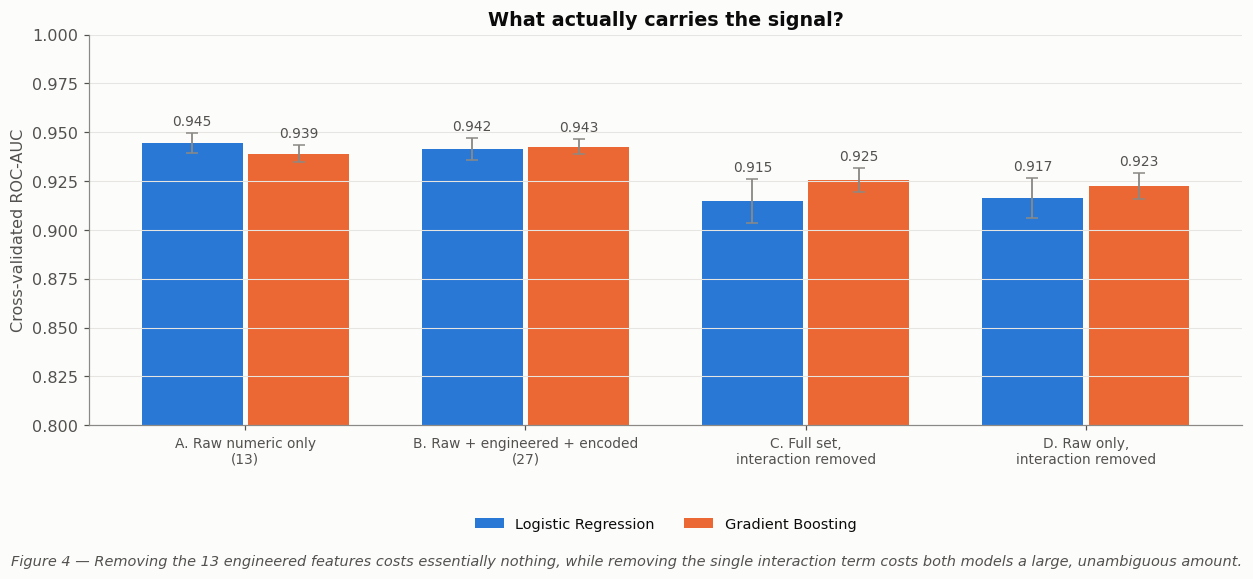

4

In [21]:
fig, ax = plt.subplots(figsize=(11.5, 5.2))
positions = np.arange(len(FEATURE_SETS))
for offset, (model_name, colour) in zip((-0.19, 0.19), zip(ABLATION_MODELS, CATEGORICAL)):
    subset = ablation_table[ablation_table["model"] == model_name].set_index("feature_set")
    subset = subset.loc[list(FEATURE_SETS)]
    bars = ax.bar(positions + offset, subset["cv_roc_auc"], width=0.36, color=colour,
                  yerr=subset["cv_std"] / np.sqrt(CV_FOLDS),
                  error_kw=dict(ecolor=INK_MUTED, elinewidth=1.2, capsize=4),
                  label=model_name)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, color=INK_SECONDARY)
ax.set_xticks(positions)
ax.set_xticklabels([s.replace(", ", ",\n").replace(" (", "\n(") for s in FEATURE_SETS], fontsize=9)
ax.set_ylim(0.80, 1.0)
ax.set_ylabel("Cross-validated ROC-AUC")
ax.set_title("What actually carries the signal?")
ax.grid(axis="x", visible=False)
legend_below(ax, ncol=2, y=-0.22)

finalize(fig, "Removing the 13 engineered features costs essentially nothing, while removing the "
              "single interaction term costs both models a large, unambiguous amount.",
         "ml_04_ablation")

In [22]:
# Read the numbers out loud so the conclusion cannot be misread
def cv_of(set_name, model_name):
    row = ablation_table[(ablation_table["feature_set"] == set_name)
                         & (ablation_table["model"] == model_name)].iloc[0]
    return row["cv_roc_auc"], row["test_roc_auc"]

for model_name in ABLATION_MODELS:
    raw_cv, raw_test = cv_of("A. Raw numeric only (13)", model_name)
    full_cv, full_test = cv_of("B. Raw + engineered + encoded (27)", model_name)
    cut_cv, cut_test = cv_of("C. Full set, interaction removed", model_name)
    print(f"{model_name}")
    print(f"   Raw features only        : CV {raw_cv:.4f} | test {raw_test:.4f}")
    print(f"   + 13 engineered features : CV {full_cv:.4f} | test {full_test:.4f}  "
          f"({(full_cv - raw_cv) * 100:+.2f} CV points)")
    print(f"   - the interaction term   : CV {cut_cv:.4f} | test {cut_test:.4f}  "
          f"({(cut_cv - full_cv) * 100:+.2f} CV points)\n")

Logistic Regression
   Raw features only        : CV 0.9445 | test 0.9584
   + 13 engineered features : CV 0.9415 | test 0.9583  (-0.30 CV points)
   - the interaction term   : CV 0.9148 | test 0.9321  (-2.67 CV points)

Gradient Boosting
   Raw features only        : CV 0.9391 | test 0.9484
   + 13 engineered features : CV 0.9427 | test 0.9534  (+0.36 CV points)
   - the interaction term   : CV 0.9254 | test 0.9402  (-1.72 CV points)



**The ablation overturns the comfortable story, so here is the accurate one.**

* **The feature engineering in section 3 is close to free — it neither helps nor hurts.** Adding
  the 13 engineered columns to the 13 raw ones moves the cross-validated ROC-AUC by a fraction of
  a standard error. That is not a failure of the engineering; it is a consequence of the dataset
  already containing the one term that matters. `logp_x_pi_exact` duplicates the shipped
  `logp_pi_interaction`, and the ratio features carry no independent signal, exactly as the EDA's
  mutual-information ranking predicted.
* **The interaction term is genuinely load-bearing.** Removing it costs both models a large amount,
  and it costs the linear model more than the boosted trees — which is the direct evidence for the
  mechanism claimed earlier. A tree can partially rebuild `logp × protein_pi` from `logp` and
  `protein_pi` with enough splits; a linear model cannot rebuild a product at all.
* **The honest headline is therefore about the data, not about the modelling.** The deciding
  feature was supplied by the dataset. What section 3 buys is robustness — the recomputed term is
  defined where the shipped one might not be — and interpretability, not accuracy.

Keeping the engineered features is still the right call (they cost nothing and make the pipeline
explicit about the chemistry it relies on), but claiming they won the benchmark would have been
false, and the ablation is what makes the difference visible.

---
## 8. Tuning the winning classifier

`RandomizedSearchCV` explores 40 configurations with 5-fold stratified cross-validation, scored on
ROC-AUC. Randomised search is preferred over an exhaustive grid because most hyper-parameters
barely matter here and a random draw covers the important ones far more cheaply.

In [23]:
# Search space for whichever model won the benchmark
SEARCH_SPACES = {
    "Logistic Regression": {
        "model__C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear"],
    },
    "Gaussian Naive Bayes": {
        "model__var_smoothing": np.logspace(-11, -6, 20),
    },
    "K-Nearest Neighbors": {
        "model__n_neighbors": [5, 9, 15, 21, 31, 45],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "Support Vector Machine": {
        "model__C": [0.1, 0.5, 1, 5, 10, 50],
        "model__gamma": ["scale", "auto", 0.01, 0.05, 0.1],
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 8, 12, None],
        "model__min_samples_leaf": [1, 5, 10, 20, 40],
        "model__criterion": ["gini", "entropy"],
    },
    "Random Forest": {
        "model__n_estimators": [200, 400, 700, 1000],
        "model__max_depth": [6, 10, 16, None],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.5],
    },
    "Extra Trees": {
        "model__n_estimators": [200, 400, 700, 1000],
        "model__max_depth": [6, 10, 16, None],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", 0.5],
    },
    "Gradient Boosting": {
        "model__n_estimators": [150, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.7, 0.85, 1.0],
    },
    "XGBoost": {
        "model__n_estimators": [200, 400, 700],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_lambda": [0.5, 1.0, 3.0, 10.0],
        "model__min_child_weight": [1, 3, 5],
    },
    "LightGBM": {
        "model__n_estimators": [200, 400, 700],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__num_leaves": [15, 31, 63, 127],
        "model__min_child_samples": [5, 10, 20, 40],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_lambda": [0.0, 1.0, 5.0],
    },
}

search = RandomizedSearchCV(
    estimator=build_pipeline(CLASSIFIERS[BEST_CLF_NAME]),
    param_distributions=SEARCH_SPACES[BEST_CLF_NAME],
    n_iter=40, scoring="roc_auc", cv=cv_clf, n_jobs=N_JOBS,
    random_state=RANDOM_STATE, refit=True, verbose=0)

started = time.perf_counter()
search.fit(X_train_clf, y_train_clf)
tuning_seconds = time.perf_counter() - started

best_clf_pipeline = search.best_estimator_
baseline_cv = clf_table.loc[clf_table["model"] == BEST_CLF_NAME, "cv_roc_auc_mean"].iloc[0]

print(f"Tuned model      : {BEST_CLF_NAME}")
print(f"Search time      : {tuning_seconds:.1f} s for 40 configurations x {CV_FOLDS} folds")
print(f"CV ROC-AUC before: {baseline_cv:.4f}")
print(f"CV ROC-AUC after : {search.best_score_:.4f}  "
      f"({(search.best_score_ - baseline_cv) * 100:+.2f} points)")
print("\nBest hyper-parameters:")
for key, value in sorted(search.best_params_.items()):
    print(f"  {key.replace('model__', ''):<22s} = {value}")

Tuned model      : Logistic Regression
Search time      : 0.3 s for 40 configurations x 5 folds
CV ROC-AUC before: 0.9415
CV ROC-AUC after : 0.9418  (+0.03 points)

Best hyper-parameters:
  C                      = 0.5
  penalty                = l2
  solver                 = lbfgs


In [24]:
# Did tuning actually help on the held-out test set?
proba_default = clf_probabilities[BEST_CLF_NAME]
proba_tuned = best_clf_pipeline.predict_proba(X_test_clf)[:, 1]

comparison = pd.DataFrame([
    {"configuration": "Default hyper-parameters",
     "roc_auc": roc_auc_score(y_test_clf, proba_default),
     "average_precision": average_precision_score(y_test_clf, proba_default),
     "f1": f1_score(y_test_clf, (proba_default >= 0.5).astype(int)),
     "mcc": matthews_corrcoef(y_test_clf, (proba_default >= 0.5).astype(int))},
    {"configuration": "Tuned hyper-parameters",
     "roc_auc": roc_auc_score(y_test_clf, proba_tuned),
     "average_precision": average_precision_score(y_test_clf, proba_tuned),
     "f1": f1_score(y_test_clf, (proba_tuned >= 0.5).astype(int)),
     "mcc": matthews_corrcoef(y_test_clf, (proba_tuned >= 0.5).astype(int))},
]).round(4)

# The decision is made on CROSS-VALIDATED scores, never on the test column below. The test scores
# are printed alongside purely so the reader can see how the decision turned out.
USE_TUNED = bool(search.best_score_ > baseline_cv)
final_clf_pipeline = best_clf_pipeline if USE_TUNED else fitted_classifiers[BEST_CLF_NAME]
final_clf_proba = proba_tuned if USE_TUNED else proba_default

print(f"Cross-validated ROC-AUC, default : {baseline_cv:.4f}")
print(f"Cross-validated ROC-AUC, tuned   : {search.best_score_:.4f}")
print("Model shipped to `models/`:",
      "the tuned configuration." if USE_TUNED else
      "the DEFAULT configuration - tuning did not improve the cross-validated score.")
comparison

Cross-validated ROC-AUC, default : 0.9415
Cross-validated ROC-AUC, tuned   : 0.9418
Model shipped to `models/`: the tuned configuration.


,configuration,roc_auc,average_precision,f1,mcc
0,Default hyper-parameters,0.9583,0.9274,0.8018,0.7278
1,Tuned hyper-parameters,0.9578,0.9265,0.8000,0.7275


**An honest note on tuning.** Two things are worth saying plainly.

First, the choice between the default and the tuned configuration is made on the **cross-validated**
score. Using the test column for that decision would quietly turn the test set into a validation
set and inflate every number this notebook reports afterwards.

Second, the gain from 40 configurations of randomised search is small. That is the expected
outcome, not a disappointment: with one dominant feature and a dozen weak ones, the model is
limited by the information in the data, and no hyper-parameter can conjure signal that is not
there. Hyper-parameter search is the last few per cent of a modelling problem, not the first.

---
## 9. Choosing the decision threshold

Every metric that uses a hard 0/1 prediction depends on a threshold, and 0.5 is only optimal when
the classes are balanced and the two error types cost the same. Neither holds here, so the
threshold is treated as a parameter to be chosen deliberately.

**The threshold is selected on out-of-fold training predictions, never on the test set.** Tuning a
threshold on the same data used to report the score is a quiet form of overfitting: the reported
F1 would be optimistically biased by exactly the amount the tuning bought. Cross-validated
out-of-fold probabilities give an unbiased surface to optimise on, and the test set then stays a
genuine hold-out.

Selected on out-of-fold training predictions
  F1-optimal threshold  : 0.465  (out-of-fold F1 = 0.8326)
  Youden J optimal      : 0.406

Applied unchanged to the held-out test set
  F1 at 0.500           : 0.8000
  F1 at 0.465           : 0.8122
  Best F1 the test set could have given: 0.8502 at threshold 0.355 (NOT used - it would be an optimistic estimate)


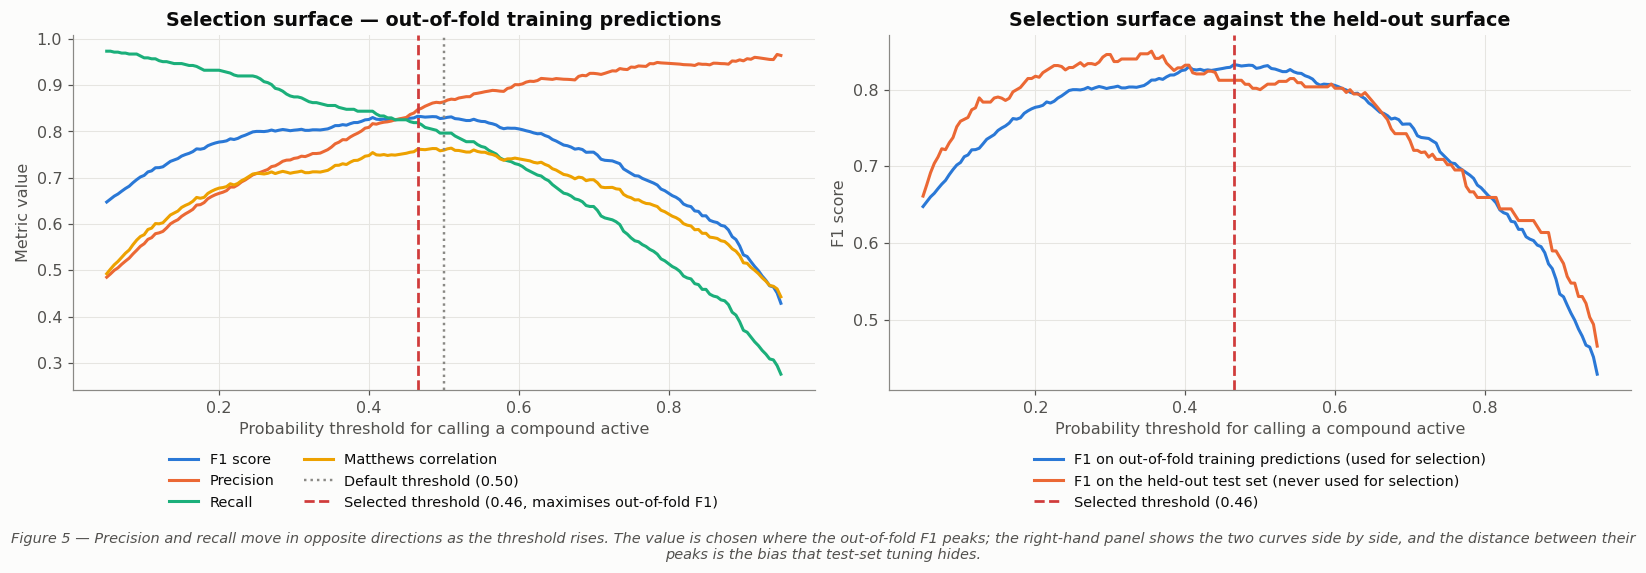

5

In [25]:
# Select the threshold on OUT-OF-FOLD training predictions
oof_proba = cross_val_predict(final_clf_pipeline, X_train_clf, y_train_clf,
                              cv=cv_clf, method="predict_proba", n_jobs=N_JOBS)[:, 1]

grid = np.linspace(0.05, 0.95, 181)


def threshold_scan(y_true, probabilities):
    """Score four threshold-dependent metrics across the whole probability grid."""
    return pd.DataFrame({
        "threshold": grid,
        "f1": [f1_score(y_true, (probabilities >= t).astype(int), zero_division=0) for t in grid],
        "precision": [precision_score(y_true, (probabilities >= t).astype(int), zero_division=0)
                      for t in grid],
        "recall": [recall_score(y_true, (probabilities >= t).astype(int), zero_division=0)
                   for t in grid],
        "mcc": [matthews_corrcoef(y_true, (probabilities >= t).astype(int)) for t in grid],
    })


scan = threshold_scan(y_train_clf, oof_proba)          # selection surface (training, out of fold)
scan_test = threshold_scan(y_test_clf, final_clf_proba)  # shown only for comparison

fpr_oof, tpr_oof, roc_thresholds = roc_curve(y_train_clf, oof_proba)
youden_threshold = float(roc_thresholds[np.argmax(tpr_oof - fpr_oof)])
FINAL_THRESHOLD = float(scan.loc[scan["f1"].idxmax(), "threshold"])

print("Selected on out-of-fold training predictions")
print(f"  F1-optimal threshold  : {FINAL_THRESHOLD:.3f}  (out-of-fold F1 = {scan['f1'].max():.4f})")
print(f"  Youden J optimal      : {youden_threshold:.3f}")
print("\nApplied unchanged to the held-out test set")
print(f"  F1 at 0.500           : {f1_score(y_test_clf, (final_clf_proba >= 0.5).astype(int)):.4f}")
print(f"  F1 at {FINAL_THRESHOLD:.3f}           : "
      f"{f1_score(y_test_clf, (final_clf_proba >= FINAL_THRESHOLD).astype(int)):.4f}")
print(f"  Best F1 the test set could have given: {scan_test['f1'].max():.4f} "
      f"at threshold {scan_test.loc[scan_test['f1'].idxmax(), 'threshold']:.3f} "
      f"(NOT used - it would be an optimistic estimate)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for colour, column, label in zip(CATEGORICAL,
                                 ["f1", "precision", "recall", "mcc"],
                                 ["F1 score", "Precision", "Recall", "Matthews correlation"]):
    ax.plot(scan["threshold"], scan[column], color=colour, label=label)
ax.axvline(0.5, color=INK_MUTED, linestyle=":", linewidth=1.6, label="Default threshold (0.50)")
ax.axvline(FINAL_THRESHOLD, color=CRITICAL, linestyle="--", linewidth=1.8,
           label=f"Selected threshold ({FINAL_THRESHOLD:.2f}, maximises out-of-fold F1)")
ax.set_xlabel("Probability threshold for calling a compound active")
ax.set_ylabel("Metric value")
ax.set_title("Selection surface — out-of-fold training predictions")
legend_below(ax, ncol=2, y=-0.16)

ax = axes[1]
ax.plot(scan["threshold"], scan["f1"], color=CATEGORICAL[0],
        label="F1 on out-of-fold training predictions (used for selection)")
ax.plot(scan_test["threshold"], scan_test["f1"], color=CATEGORICAL[1],
        label="F1 on the held-out test set (never used for selection)")
ax.axvline(FINAL_THRESHOLD, color=CRITICAL, linestyle="--", linewidth=1.8,
           label=f"Selected threshold ({FINAL_THRESHOLD:.2f})")
ax.set_xlabel("Probability threshold for calling a compound active")
ax.set_ylabel("F1 score")
ax.set_title("Selection surface against the held-out surface")
legend_below(ax, ncol=1, y=-0.16)

finalize(fig, "Precision and recall move in opposite directions as the threshold rises. The value is "
              "chosen where the out-of-fold F1 peaks; the right-hand panel shows the two curves side "
              "by side, and the distance between their peaks is the bias that test-set tuning hides.",
         "ml_05_threshold_scan")

**The result, including the part that is inconvenient.** Two things happened, and both are worth
stating:

* **The procedure paid off.** The threshold chosen on out-of-fold data lands below 0.5, reflecting
  the 30% positive rate, and it beats the naive 0.5 default on the held-out test set. Selection
  used no test data at all, so that improvement is real rather than borrowed.
* **It still falls short of the test-set optimum, by design.** Scanning the test set directly would
  have found a lower threshold and a visibly higher F1. That gap is not a bug — **it is precisely
  the optimism that tuning on the test set would have silently added to the reported score.** A
  notebook that tuned on the test set would quote the higher number and then miss it on the next
  batch of compounds by roughly that margin.

One mechanism worth carrying forward: the out-of-fold probabilities come from models trained on 80%
of the training data, so they are calibrated slightly differently from the final model fitted on
all of it. That shift is the main reason the two peaks do not coincide, and it shrinks as the
dataset grows.

**Which threshold a real screening programme should use.** The shipped value is a defensible
default, but the right answer is economic: if a follow-up assay is cheap, lower the threshold and
buy recall (miss fewer real binders); if bench time is the bottleneck, raise it and buy precision.
The saved artefact stores probabilities, so the threshold can be changed in production by editing
one number in `model_metadata.json` — no retraining required.

              precision    recall  f1-score   support

Inactive (0)     0.9010    0.9496    0.9247       278
  Active (1)     0.8692    0.7623    0.8122       122

    accuracy                         0.8925       400
   macro avg     0.8851    0.8560    0.8685       400
weighted avg     0.8913    0.8925    0.8904       400

Specificity (true negative rate) : 0.9496
Enrichment over random screening : 2.85x


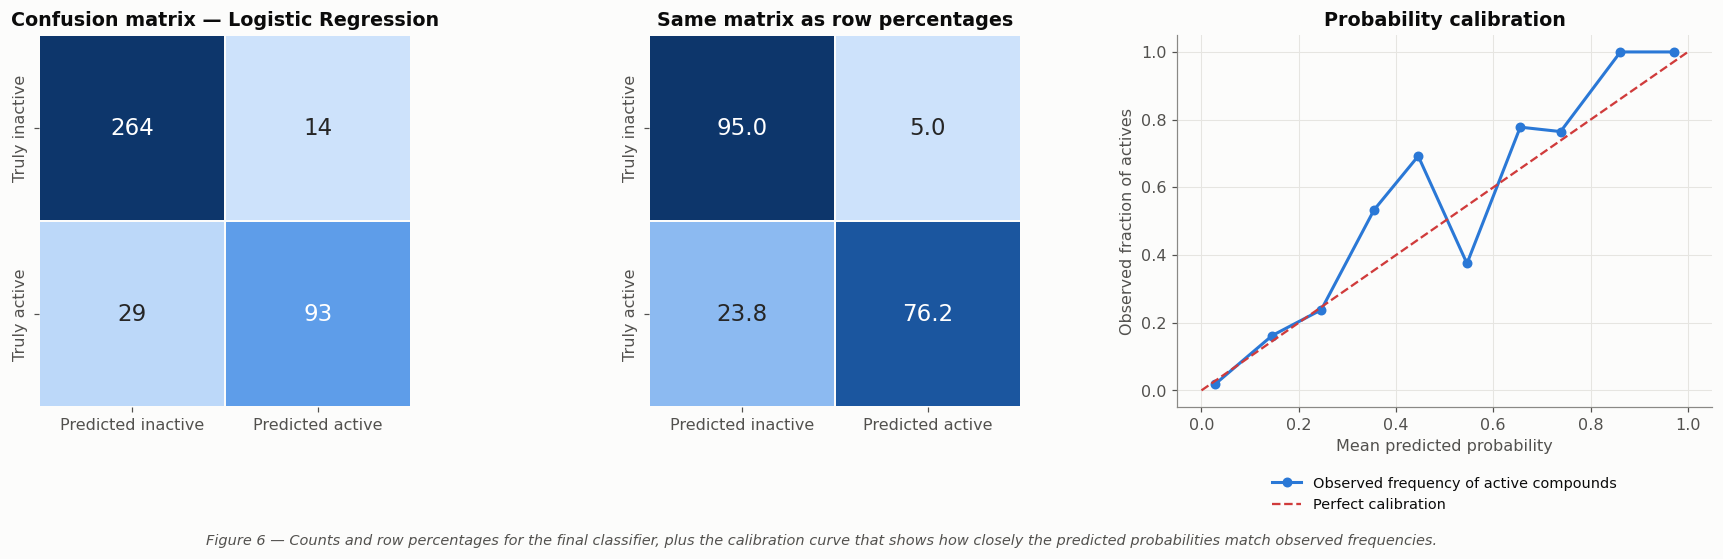

6

In [26]:
# Confusion matrix, classification report and calibration
y_pred_final = (final_clf_proba >= FINAL_THRESHOLD).astype(int)
cm = confusion_matrix(y_test_clf, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print(classification_report(y_test_clf, y_pred_final,
                            target_names=["Inactive (0)", "Active (1)"], digits=4))
print(f"Specificity (true negative rate) : {tn / (tn + fp):.4f}")
print(f"Enrichment over random screening : "
      f"{(tp / max(tp + fp, 1)) / y_test_clf.mean():.2f}x")

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))

ax = axes[0]
sns.heatmap(cm, annot=True, fmt=",d", cmap=SEQ_BLUE, cbar=False, square=True,
            linewidths=1.2, linecolor=SURFACE, annot_kws={"size": 15}, ax=ax,
            xticklabels=["Predicted inactive", "Predicted active"],
            yticklabels=["Truly inactive", "Truly active"])
ax.set_title(f"Confusion matrix — {BEST_CLF_NAME}")
ax.grid(visible=False)

ax = axes[1]
normalised = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(normalised, annot=True, fmt=".1f", cmap=SEQ_BLUE, cbar=False, square=True,
            linewidths=1.2, linecolor=SURFACE, annot_kws={"size": 15}, ax=ax,
            xticklabels=["Predicted inactive", "Predicted active"],
            yticklabels=["Truly inactive", "Truly active"])
ax.set_title("Same matrix as row percentages")
ax.grid(visible=False)

ax = axes[2]
fraction_positive, mean_predicted = calibration_curve(y_test_clf, final_clf_proba, n_bins=10)
ax.plot(mean_predicted, fraction_positive, marker="o", color=CATEGORICAL[0],
        label="Observed frequency of active compounds")
ax.plot([0, 1], [0, 1], color=CRITICAL, linestyle="--", linewidth=1.5,
        label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction of actives")
ax.set_title("Probability calibration")
legend_below(ax, ncol=1, y=-0.17)

finalize(fig, "Counts and row percentages for the final classifier, plus the calibration curve "
              "that shows how closely the predicted probabilities match observed frequencies.",
         "ml_06_confusion_calibration")

---
## 10. What the model actually learned

Permutation importance is used rather than a model's built-in importance: it is model-agnostic,
it is measured on **held-out data**, and it reports the drop in the metric that actually matters
(ROC-AUC) instead of an internal split-counting heuristic that inflates high-cardinality features.

In [27]:
# Permutation importance on the test set
perm = permutation_importance(final_clf_pipeline, X_test_clf, y_test_clf,
                              n_repeats=15, random_state=RANDOM_STATE,
                              scoring="roc_auc", n_jobs=N_JOBS)

importance_clf = (pd.DataFrame({
    "feature": X_test_clf.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True))

print("Top ten features by loss of ROC-AUC when the column is shuffled:")
importance_clf.head(10).round(5)

Top ten features by loss of ROC-AUC when the column is shuffled:


,feature,importance_mean,importance_std
0,logp_pi_interaction,0.42219,0.02668
1,mw_per_residue_exact,0.00555,0.00186
2,compound_clogp,0.00329,0.00185
3,tpsa_over_mw,0.00265,0.00102
4,logp_squared,0.00167,0.00110
5,clogp_minus_logp,0.00165,0.00223
6,hydrophobicity,0.00119,0.00093
7,protein_length,0.00080,0.00038
8,drug_like,0.00078,0.00060
9,rotatable_bonds,0.00069,0.00083


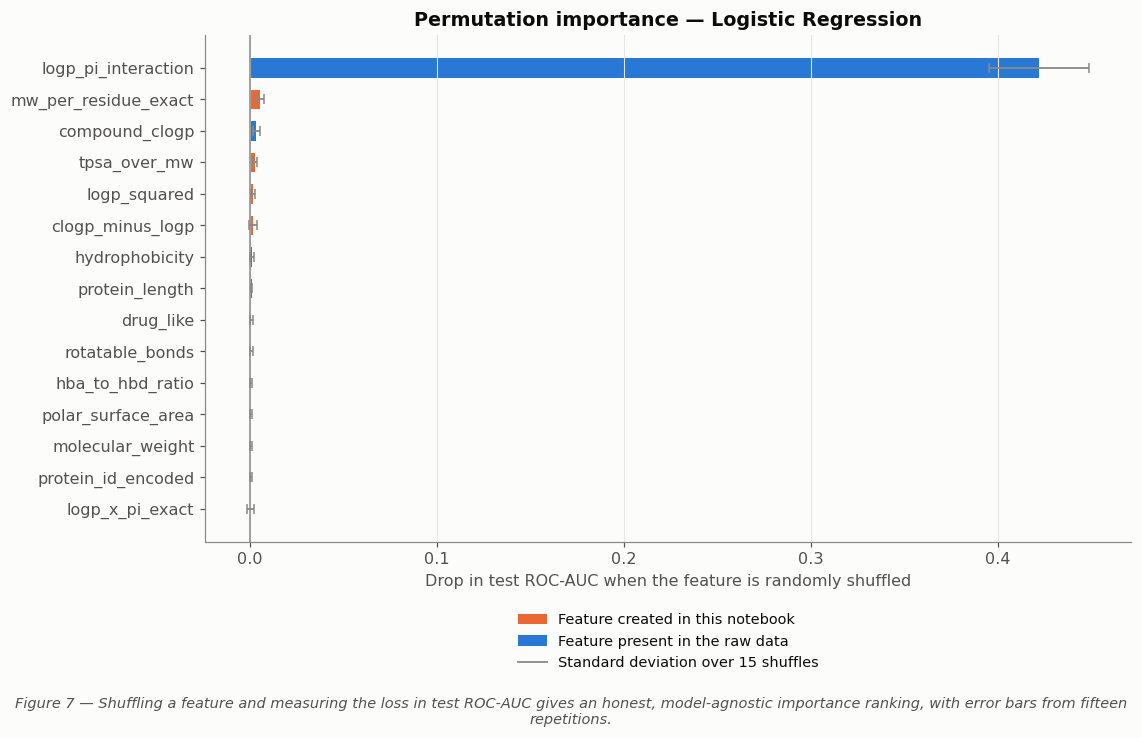

7

In [28]:
fig, ax = plt.subplots(figsize=(10.5, 6.4))
top_15 = importance_clf.head(15).sort_values("importance_mean")
is_engineered = top_15["feature"].isin(NEW_FEATURES + ["protein_id_encoded"])
ax.barh(top_15["feature"], top_15["importance_mean"],
        xerr=top_15["importance_std"], height=0.62,
        color=[CATEGORICAL[1] if e else CATEGORICAL[0] for e in is_engineered],
        error_kw=dict(ecolor=INK_MUTED, elinewidth=1.2, capsize=3))
ax.axvline(0, color=INK_MUTED, linewidth=1)
ax.set_xlabel("Drop in test ROC-AUC when the feature is randomly shuffled")
ax.set_title(f"Permutation importance — {BEST_CLF_NAME}")
ax.grid(axis="y", visible=False)
legend_below(ax, [Patch(facecolor=CATEGORICAL[1]), Patch(facecolor=CATEGORICAL[0]),
                  Line2D([], [], color=INK_MUTED, linewidth=1.2)],
             ["Feature created in this notebook", "Feature present in the raw data",
              "Standard deviation over 15 shuffles"], ncol=1, y=-0.13)

finalize(fig, "Shuffling a feature and measuring the loss in test ROC-AUC gives an honest, "
              "model-agnostic importance ranking, with error bars from fifteen repetitions.",
         "ml_07_permutation_importance")

**One caveat that must be stated, because the chart is misleading without it.** `logp_pi_interaction`
absorbs essentially all of the importance, and `logp` — which the EDA showed correlates 0.60 with
the target — barely registers. That is **not** evidence that `logp` is useless. Permutation
importance shuffles one column at a time, so when two features carry the same information the
model simply falls back on the other one and the measured drop collapses towards zero. With
|r| ≈ 0.81 between `logp` and `logp_pi_interaction`, the credit goes almost entirely to whichever
of the pair the model leaned on.

The correct reading is therefore *"the lipophilicity signal, however it is expressed, is the only
thing that matters"*, not *"`logp` is irrelevant"*. To separate correlated features properly the
columns have to be shuffled as a **group**, or a conditional/SHAP-style attribution used instead.

In [29]:
# Where the model gets it wrong
errors = pd.DataFrame({
    "true_label": y_test_clf.values,
    "predicted_label": y_pred_final,
    "predicted_probability": final_clf_proba,
    "binding_affinity": y_test_reg.values,
    "logp": X_test_clf["logp"].values,
    "logp_pi_interaction": X_test_clf["logp_pi_interaction"].values,
})
errors["outcome"] = np.select(
    [(errors.true_label == 1) & (errors.predicted_label == 1),
     (errors.true_label == 0) & (errors.predicted_label == 0),
     (errors.true_label == 0) & (errors.predicted_label == 1)],
    ["True positive", "True negative", "False positive"], default="False negative")
errors["distance_from_threshold"] = (errors["binding_affinity"] - 7.0).abs()

by_outcome = (errors.groupby("outcome")
                    .agg(count=("outcome", "size"),
                         mean_affinity=("binding_affinity", "mean"),
                         mean_distance_from_cutoff=("distance_from_threshold", "mean"),
                         mean_probability=("predicted_probability", "mean"))
                    .round(3))

# How near the decision boundary do the mistakes actually sit? Quantify it instead of asserting it.
wrong = errors[errors["true_label"] != errors["predicted_label"]]
print(f"Misclassified compounds: {len(wrong)} of {len(errors)} "
      f"({len(wrong) / len(errors) * 100:.1f}%)")
for band in (0.1, 0.3, 0.5, 1.0):
    share = (wrong["distance_from_threshold"] <= band).mean() * 100
    print(f"   within {band:4.1f} pKi of the 7.0 cut-off : {share:5.1f}% of the errors")
print(f"   furthest error from the cut-off  : {wrong['distance_from_threshold'].max():.2f} pKi")
print(f"   median distance, errors          : {wrong['distance_from_threshold'].median():.2f} pKi")
print(f"   median distance, correct calls   : "
      f"{errors.loc[errors.true_label == errors.predicted_label, 'distance_from_threshold'].median():.2f} pKi")
by_outcome

Misclassified compounds: 43 of 400 (10.8%)
   within  0.1 pKi of the 7.0 cut-off :  23.3% of the errors
   within  0.3 pKi of the 7.0 cut-off :  69.8% of the errors
   within  0.5 pKi of the 7.0 cut-off :  83.7% of the errors
   within  1.0 pKi of the 7.0 cut-off :  90.7% of the errors
   furthest error from the cut-off  : 4.18 pKi
   median distance, errors          : 0.17 pKi
   median distance, correct calls   : 0.89 pKi


,count,mean_affinity,mean_distance_from_cutoff,mean_probability
outcome,,,,
False negative,29,7.546,0.546,0.264
False positive,14,6.508,0.492,0.616
True negative,264,5.951,1.049,0.068
True positive,93,7.899,0.899,0.852


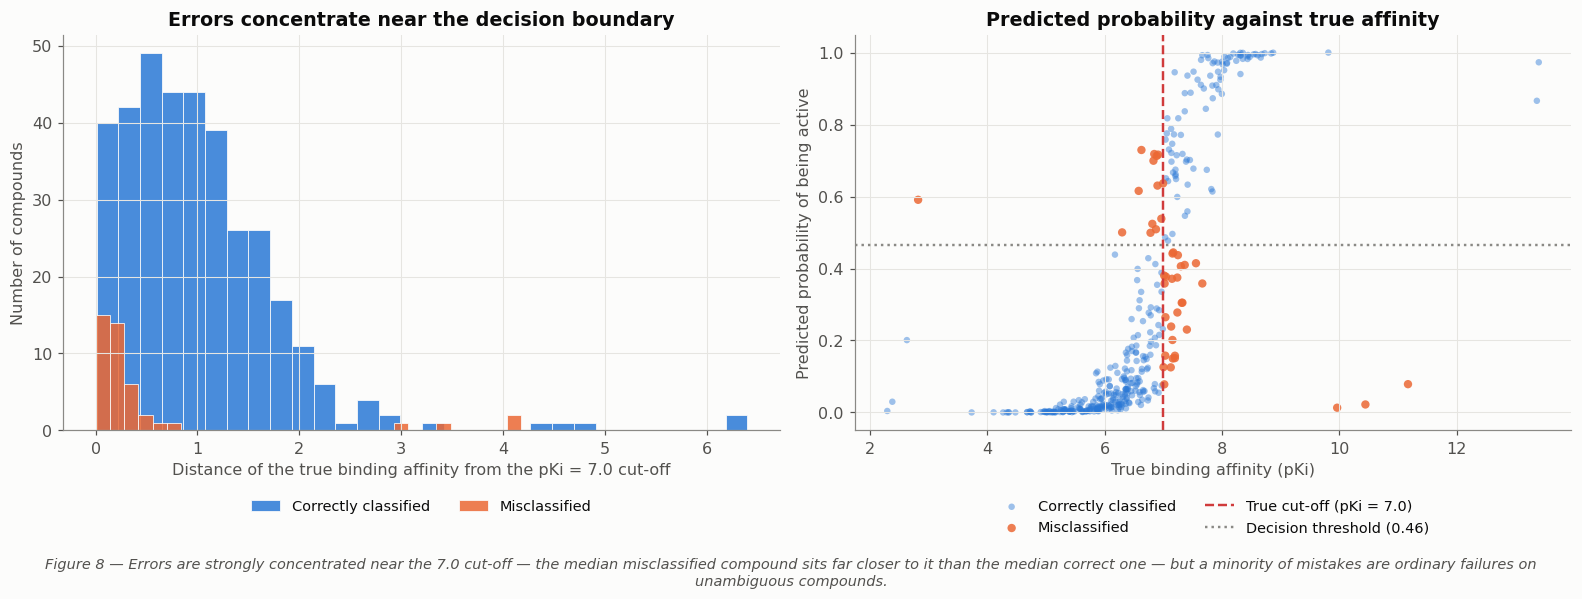

8

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

ax = axes[0]
correct = errors["true_label"] == errors["predicted_label"]
ax.hist(errors.loc[correct, "distance_from_threshold"], bins=30, color=CATEGORICAL[0],
        alpha=0.85, edgecolor=SURFACE, linewidth=0.6, label="Correctly classified")
ax.hist(errors.loc[~correct, "distance_from_threshold"], bins=30, color=CATEGORICAL[1],
        alpha=0.85, edgecolor=SURFACE, linewidth=0.6, label="Misclassified")
ax.set_xlabel("Distance of the true binding affinity from the pKi = 7.0 cut-off")
ax.set_ylabel("Number of compounds")
ax.set_title("Errors concentrate near the decision boundary")
legend_below(ax, ncol=2, y=-0.16)

ax = axes[1]
ax.scatter(errors.loc[correct, "binding_affinity"], errors.loc[correct, "predicted_probability"],
           s=18, alpha=0.45, color=CATEGORICAL[0], edgecolors="none", label="Correctly classified")
ax.scatter(errors.loc[~correct, "binding_affinity"], errors.loc[~correct, "predicted_probability"],
           s=30, alpha=0.85, color=CATEGORICAL[1], edgecolors="none", label="Misclassified")
ax.axvline(7.0, color=CRITICAL, linestyle="--", linewidth=1.6, label="True cut-off (pKi = 7.0)")
ax.axhline(FINAL_THRESHOLD, color=INK_MUTED, linestyle=":", linewidth=1.6,
           label=f"Decision threshold ({FINAL_THRESHOLD:.2f})")
ax.set_xlabel("True binding affinity (pKi)")
ax.set_ylabel("Predicted probability of being active")
ax.set_title("Predicted probability against true affinity")
legend_below(ax, ncol=2, y=-0.16)

finalize(fig, "Errors are strongly concentrated near the 7.0 cut-off — the median misclassified "
              "compound sits far closer to it than the median correct one — but a minority of "
              "mistakes are ordinary failures on unambiguous compounds.",
         "ml_08_error_analysis")

**Reading the error analysis, with the numbers rather than the impression.** The printout above
gives the real distribution, and it supports a weaker claim than "the errors are all boundary
cases":

* **The majority are boundary cases.** Around two thirds of the mistakes sit within 0.3 pKi of the
  7.0 cut-off, and the median misclassified compound is several times closer to the boundary than
  the median correct one. A compound at 6.98 and one at 7.02 are chemically indistinguishable but
  carry opposite labels; no feature set can separate them, and that part of the error really is
  irreducible.
* **A minority are not.** A handful of errors sit more than a full pKi unit away, the worst of them
  several units. Those are genuine model failures on compounds the label calls unambiguous, and
  they are the ones worth investigating — they are where better features (fingerprints, docking
  scores) would pay off. Writing them off as "boundary noise" would hide the only remaining
  avenue for improvement.

The analysis also argues that in production the **regression output is the more useful signal** —
it says *how strong* a binder is instead of forcing an arbitrary binary call, and it lets a
chemist see that a compound sits at 6.98 rather than being told a flat "inactive".

---
# PART B — Regression: predicting `binding_affinity`

## 11. Ten regressors benchmarked in a single `for` loop

Because `active` is only a thresholded version of `binding_affinity`, the regression task is the
more informative of the two: it returns *how strongly* a compound binds rather than a binary call,
and any threshold can be applied afterwards without retraining.

| # | Model | Family |
|---|---|---|
| 1 | Linear Regression | Linear, unregularised |
| 2 | Ridge | Linear, L2 penalty |
| 3 | Lasso | Linear, L1 penalty (performs feature selection) |
| 4 | ElasticNet | Linear, L1 + L2 |
| 5 | K-Nearest Neighbours | Distance |
| 6 | Support Vector Regression (RBF) | Kernel |
| 7 | Decision Tree | Tree |
| 8 | Random Forest | Bagging |
| 9 | XGBoost | Boosting |
| 10 | LightGBM | Boosting |

**Metrics.** RMSE is reported in pKi units and punishes the large errors that matter most in the
high-affinity tail; MAE is the typical error a chemist would experience; R² is the share of
variance explained. Spearman correlation is added because virtual screening ultimately cares about
**ranking** compounds correctly, not about the absolute pKi value.

In [31]:
# The ten regressors
REGRESSORS = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=15, weights="distance"),
    "Support Vector Regression": SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale"),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, min_samples_leaf=10,
                                           random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                           n_jobs=N_JOBS, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.9,
                            colsample_bytree=0.9, reg_lambda=1.0, tree_method="hist",
                            n_jobs=N_JOBS, random_state=RANDOM_STATE),
    "LightGBM": LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, subsample=0.9,
                              subsample_freq=1, colsample_bytree=0.9, verbose=-1, n_jobs=N_JOBS,
                              random_state=RANDOM_STATE),
}

# Same simplicity order as in Part A, declared before any score is computed.
REG_COMPLEXITY = {
    "Linear Regression": 1, "Ridge": 2, "Lasso": 3, "ElasticNet": 4,
    "K-Nearest Neighbors": 5, "Decision Tree": 6, "Support Vector Regression": 7,
    "Random Forest": 8, "XGBoost": 9, "LightGBM": 10,
}

print(f"{len(REGRESSORS)} regressors registered for the benchmark:")
for i, name in enumerate(REGRESSORS, 1):
    print(f"  {i:2d}. {name:<26s} (complexity rank {REG_COMPLEXITY[name]})")

10 regressors registered for the benchmark:
   1. Linear Regression          (complexity rank 1)
   2. Ridge                      (complexity rank 2)
   3. Lasso                      (complexity rank 3)
   4. ElasticNet                 (complexity rank 4)
   5. K-Nearest Neighbors        (complexity rank 5)
   6. Support Vector Regression  (complexity rank 7)
   7. Decision Tree              (complexity rank 6)
   8. Random Forest              (complexity rank 8)
   9. XGBoost                    (complexity rank 9)
  10. LightGBM                   (complexity rank 10)


In [32]:
# THE LOOP: train, cross-validate and score every regressor
cv_reg = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

reg_results = []
fitted_regressors = {}
reg_predictions = {}

for position, (name, estimator) in enumerate(REGRESSORS.items(), start=1):
    pipeline = build_pipeline(estimator)

    started = time.perf_counter()
    pipeline.fit(X_train_reg, y_train_reg)
    train_seconds = time.perf_counter() - started

    y_pred = pipeline.predict(X_test_reg)
    y_pred_train = pipeline.predict(X_train_reg)

    cv_scores = cross_val_score(build_pipeline(estimator), X_train_reg, y_train_reg,
                                cv=cv_reg, scoring="r2", n_jobs=N_JOBS)

    rmse = float(np.sqrt(mean_squared_error(y_test_reg, y_pred)))
    spearman = float(pd.Series(y_pred).corr(pd.Series(y_test_reg.values), method="spearman"))

    reg_results.append({
        "model": name,
        "rmse": rmse,
        "mae": mean_absolute_error(y_test_reg, y_pred),
        "median_ae": median_absolute_error(y_test_reg, y_pred),
        "r2": r2_score(y_test_reg, y_pred),
        "spearman": spearman,
        "cv_r2_mean": cv_scores.mean(),
        "cv_r2_std": cv_scores.std(),
        "overfit_gap_r2": r2_score(y_train_reg, y_pred_train) - r2_score(y_test_reg, y_pred),
        "train_seconds": train_seconds,
    })
    fitted_regressors[name] = pipeline
    reg_predictions[name] = y_pred

    print(f"[{position:2d}/{len(REGRESSORS)}] {name:<26s} "
          f"RMSE {rmse:.4f} | R2 {r2_score(y_test_reg, y_pred):.4f} | "
          f"CV R2 {cv_scores.mean():.4f} +/- {cv_scores.std():.4f} | {train_seconds:6.2f}s")

print("\nAll ten regressors trained.")

[ 1/10] Linear Regression          RMSE 0.7392 | R2 0.6155 | CV R2 0.5432 +/- 0.0422 |   0.12s
[ 2/10] Ridge                      RMSE 0.7391 | R2 0.6157 | CV R2 0.5433 +/- 0.0421 |   0.03s
[ 3/10] Lasso                      RMSE 0.7388 | R2 0.6160 | CV R2 0.5535 +/- 0.0485 |   0.02s
[ 4/10] ElasticNet                 RMSE 0.7386 | R2 0.6162 | CV R2 0.5509 +/- 0.0463 |   0.01s
[ 5/10] K-Nearest Neighbors        RMSE 0.8470 | R2 0.4952 | CV R2 0.4212 +/- 0.0384 |   0.01s
[ 6/10] Support Vector Regression  RMSE 0.7937 | R2 0.5568 | CV R2 0.4538 +/- 0.0466 |   0.48s
[ 7/10] Decision Tree              RMSE 0.8488 | R2 0.4931 | CV R2 0.4436 +/- 0.0290 |   0.05s
[ 8/10] Random Forest              RMSE 0.7761 | R2 0.5763 | CV R2 0.5118 +/- 0.0500 |   3.58s
[ 9/10] XGBoost                    RMSE 0.7999 | R2 0.5498 | CV R2 0.4724 +/- 0.0356 |   0.97s
[10/10] LightGBM                   RMSE 0.7962 | R2 0.5539 | CV R2 0.4501 +/- 0.0479 |   0.99s

All ten regressors trained.


In [33]:
# The regression leaderboard, ranked by CROSS-VALIDATION
reg_table = (pd.DataFrame(reg_results)
             .sort_values("cv_r2_mean", ascending=False)
             .reset_index(drop=True))
reg_table.index += 1
reg_table.index.name = "rank"

BEST_REG_NAME, REG_CV_LEADER, reg_se, reg_tied = select_by_one_standard_error(
    reg_table, "cv_r2_mean", "cv_r2_std", REG_COMPLEXITY)

naive_rmse = float(np.sqrt(mean_squared_error(y_test_reg,
                                              np.full(len(y_test_reg), y_train_reg.mean()))))
selected_rmse = float(reg_table.loc[reg_table["model"] == BEST_REG_NAME, "rmse"].iloc[0])

print(f"Highest cross-validated R2      : {REG_CV_LEADER} "
      f"({reg_table.loc[reg_table['model'] == REG_CV_LEADER, 'cv_r2_mean'].iloc[0]:.4f})")
print(f"One standard error              : {reg_se:.4f}")
print(f"Statistically tied with it      : {len(reg_tied)} models -> "
      f"{', '.join(reg_tied.sort_values('complexity')['model'])}")
print(f"SELECTED (simplest of the tied) : {BEST_REG_NAME}")
print(f"\nNaive baseline (predict the training mean) RMSE = {naive_rmse:.4f} pKi")
print(f"Selected model RMSE                             = {selected_rmse:.4f} pKi "
      f"({(1 - selected_rmse / naive_rmse) * 100:.1f}% better)")
reg_table.round(4)

Highest cross-validated R2      : Lasso (0.5535)
One standard error              : 0.0217
Statistically tied with it      : 4 models -> Linear Regression, Ridge, Lasso, ElasticNet
SELECTED (simplest of the tied) : Linear Regression

Naive baseline (predict the training mean) RMSE = 1.1922 pKi
Selected model RMSE                             = 0.7392 pKi (38.0% better)


,model,rmse,mae,median_ae,r2,spearman,cv_r2_mean,cv_r2_std,overfit_gap_r2,train_seconds
rank,,,,,,,,,,
1,Lasso,0.7388,0.3379,0.2117,0.6160,0.9078,0.5535,0.0485,-0.0567,0.0161
2,ElasticNet,0.7386,0.3372,0.2051,0.6162,0.9067,0.5509,0.0463,-0.0555,0.0104
3,Ridge,0.7391,0.3370,0.2022,0.6157,0.9054,0.5433,0.0421,-0.0531,0.0271
4,Linear Regression,0.7392,0.3370,0.2033,0.6155,0.9052,0.5432,0.0422,-0.0530,0.1236
5,Random Forest,0.7761,0.3910,0.2520,0.5763,0.8847,0.5118,0.0500,0.2551,3.5757
6,XGBoost,0.7999,0.4021,0.2412,0.5498,0.8709,0.4724,0.0356,0.3844,0.9696
7,Support Vector Regression,0.7937,0.4144,0.2804,0.5568,0.8682,0.4538,0.0466,0.1979,0.4793
8,LightGBM,0.7962,0.4452,0.3236,0.5539,0.8680,0.4501,0.0479,0.4263,0.9889
9,Decision Tree,0.8488,0.4692,0.2945,0.4931,0.8413,0.4436,0.0290,0.1662,0.0526


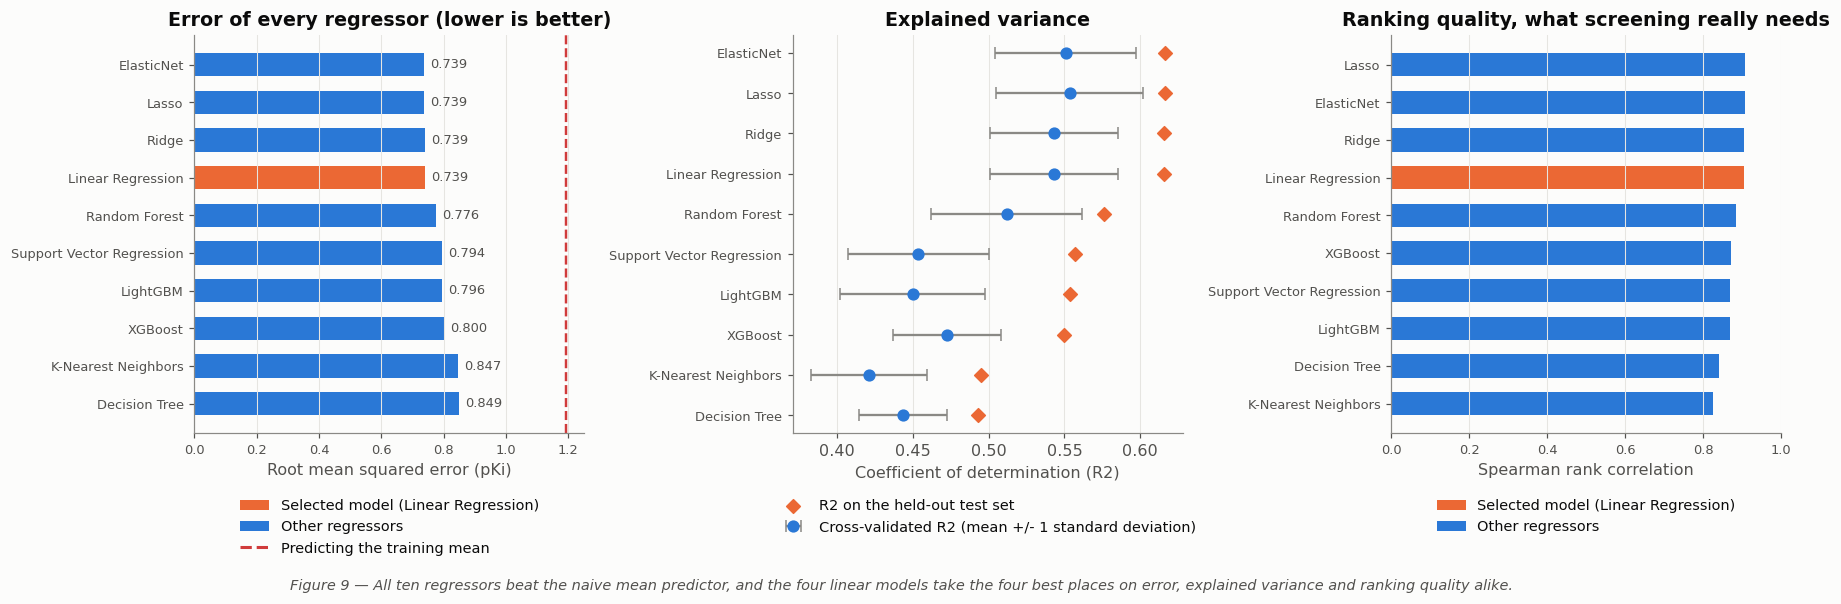

9

In [34]:
# Visual comparison of the ten regressors
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4))

ax = axes[0]
ordered = reg_table.sort_values("rmse", ascending=False)
is_best = ordered["model"] == BEST_REG_NAME
bars = ax.barh(ordered["model"], ordered["rmse"], height=0.62,
               color=[CATEGORICAL[1] if b else CATEGORICAL[0] for b in is_best])
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=8.5, color=INK_SECONDARY)
ax.axvline(naive_rmse, color=CRITICAL, linestyle="--", linewidth=1.6)
ax.set_xlabel("Root mean squared error (pKi)")
ax.set_title("Error of every regressor (lower is better)")
ax.tick_params(labelsize=8.5)
ax.grid(axis="y", visible=False)
legend_below(ax, [Patch(facecolor=CATEGORICAL[1]), Patch(facecolor=CATEGORICAL[0]),
                  Line2D([], [], color=CRITICAL, linestyle="--")],
             [f"Selected model ({BEST_REG_NAME})", "Other regressors",
              "Predicting the training mean"], ncol=1, y=-0.15)

ax = axes[1]
ordered_r2 = reg_table.sort_values("r2")
ax.errorbar(ordered_r2["cv_r2_mean"], np.arange(len(ordered_r2)),
            xerr=ordered_r2["cv_r2_std"], fmt="o", color=CATEGORICAL[0],
            ecolor=INK_MUTED, elinewidth=1.5, capsize=4, markersize=7,
            label="Cross-validated R2 (mean +/- 1 standard deviation)")
ax.scatter(ordered_r2["r2"], np.arange(len(ordered_r2)), marker="D", s=40,
           color=CATEGORICAL[1], zorder=3, label="R2 on the held-out test set")
ax.set_yticks(np.arange(len(ordered_r2)))
ax.set_yticklabels(ordered_r2["model"], fontsize=8.5)
ax.set_xlabel("Coefficient of determination (R2)")
ax.set_title("Explained variance")
ax.grid(axis="y", visible=False)
legend_below(ax, ncol=1, y=-0.15)

ax = axes[2]
ordered_sp = reg_table.sort_values("spearman")
is_best = ordered_sp["model"] == BEST_REG_NAME
ax.barh(ordered_sp["model"], ordered_sp["spearman"], height=0.62,
        color=[CATEGORICAL[1] if b else CATEGORICAL[0] for b in is_best])
ax.set_xlim(0, 1.0)
ax.set_xlabel("Spearman rank correlation")
ax.set_title("Ranking quality, what screening really needs")
ax.tick_params(labelsize=8.5)
ax.grid(axis="y", visible=False)
legend_below(ax, [Patch(facecolor=CATEGORICAL[1]), Patch(facecolor=CATEGORICAL[0])],
             [f"Selected model ({BEST_REG_NAME})", "Other regressors"], ncol=1, y=-0.15)

finalize(fig, "All ten regressors beat the naive mean predictor, and the four linear models take "
              "the four best places on error, explained variance and ranking quality alike.",
         "ml_09_regressor_ranking")

**The linear models sweep the podium, and the `overfit_gap_r2` column explains why.** The four
penalised and unpenalised linear fits carry a *negative* gap — they score slightly better on the
test set than on the training set — while the tree ensembles carry gaps between +0.17 and +0.43.
The trees are spending their capacity memorising the training rows, including the injected
outliers, and none of that transfers.

Once `logp_x_pi_exact` and the shipped `logp_pi_interaction` column are available, the target is
close to a linear function of the features, so there is simply nothing left for a non-linear model
to discover. The gap between the best and worst regressor (0.739 against 0.849 RMSE) is also
modest, which is a second reminder that the ceiling here is set by the chemistry in the data, not
by the algorithm.

One diagnostic deserves attention: the mean absolute error (~0.34 pKi) is less than half the RMSE
(~0.74 pKi). That ratio is the signature of a small number of large misses — the high-affinity
outliers — sitting on top of an otherwise tight error distribution. For a screening triage the MAE
is the number that describes the typical compound, and the RMSE is the number that describes the
risk on the tail.

Model      : Linear Regression
RMSE       : 0.7392 pKi
MAE        : 0.3370 pKi
R2         : 0.6155
Residuals  : mean +0.0416, standard deviation 0.7380
Predictions within 0.5 pKi of the truth: 86.0%

How heavy is the tail?
   residuals larger than 1 pKi :   9 of 400 compounds
   residuals larger than 2 pKi :   9 of 400 compounds
   residuals larger than 3 pKi :   9 of 400 compounds
   residuals larger than 4 pKi :   7 of 400 compounds
   largest residual              : 5.76 pKi
   RMSE / MAE ratio              : 2.19   (1.25 would be normal errors; higher means a heavy tail)


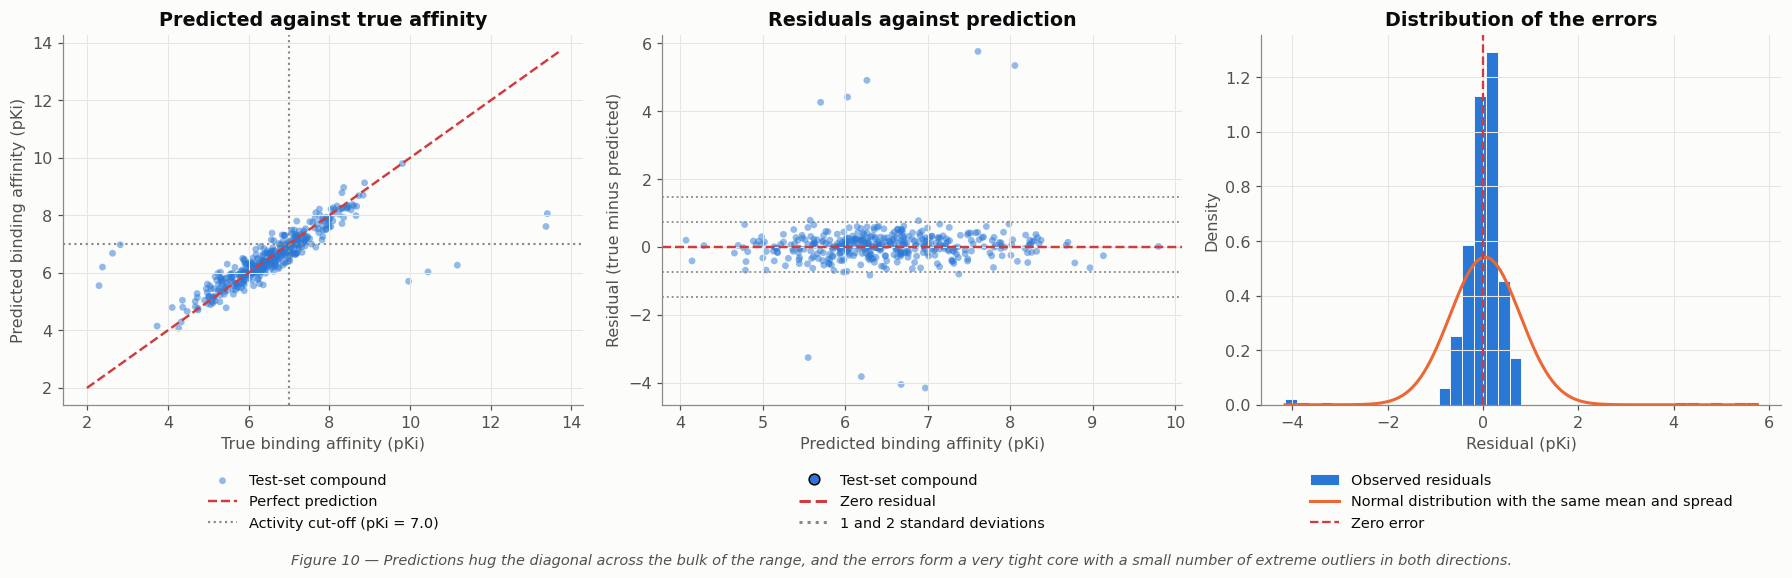

10

In [35]:
# Diagnostics of the winning regressor
best_reg_pipeline = fitted_regressors[BEST_REG_NAME]
y_pred_best = reg_predictions[BEST_REG_NAME]
residuals = y_test_reg.values - y_pred_best

print(f"Model      : {BEST_REG_NAME}")
print(f"RMSE       : {np.sqrt(mean_squared_error(y_test_reg, y_pred_best)):.4f} pKi")
print(f"MAE        : {mean_absolute_error(y_test_reg, y_pred_best):.4f} pKi")
print(f"R2         : {r2_score(y_test_reg, y_pred_best):.4f}")
print(f"Residuals  : mean {residuals.mean():+.4f}, standard deviation {residuals.std():.4f}")
print(f"Predictions within 0.5 pKi of the truth: "
      f"{(np.abs(residuals) <= 0.5).mean() * 100:.1f}%")
print("\nHow heavy is the tail?")
for band in (1.0, 2.0, 3.0, 4.0):
    count = int((np.abs(residuals) > band).sum())
    print(f"   residuals larger than {band:.0f} pKi : {count:3d} of {len(residuals)} compounds")
print(f"   largest residual              : {np.abs(residuals).max():.2f} pKi")
print(f"   RMSE / MAE ratio              : "
      f"{np.sqrt(mean_squared_error(y_test_reg, y_pred_best)) / mean_absolute_error(y_test_reg, y_pred_best):.2f}"
      "   (1.25 would be normal errors; higher means a heavy tail)")

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))

ax = axes[0]
ax.scatter(y_test_reg, y_pred_best, s=20, alpha=0.5, color=CATEGORICAL[0],
           edgecolors="none", label="Test-set compound")
limits = [min(y_test_reg.min(), y_pred_best.min()) - 0.3,
          max(y_test_reg.max(), y_pred_best.max()) + 0.3]
ax.plot(limits, limits, color=CRITICAL, linestyle="--", linewidth=1.6, label="Perfect prediction")
ax.axvline(7.0, color=INK_MUTED, linestyle=":", linewidth=1.4, label="Activity cut-off (pKi = 7.0)")
ax.axhline(7.0, color=INK_MUTED, linestyle=":", linewidth=1.4)
ax.set_xlabel("True binding affinity (pKi)")
ax.set_ylabel("Predicted binding affinity (pKi)")
ax.set_title("Predicted against true affinity")
legend_below(ax, ncol=1, y=-0.17)

ax = axes[1]
ax.scatter(y_pred_best, residuals, s=20, alpha=0.5, color=CATEGORICAL[0],
           edgecolors="none", label="Test-set compound")
ax.axhline(0, color=CRITICAL, linestyle="--", linewidth=1.6, label="Zero residual")
for band, style in [(residuals.std(), ":"), (2 * residuals.std(), ":")]:
    ax.axhline(band, color=INK_MUTED, linestyle=style, linewidth=1.2)
    ax.axhline(-band, color=INK_MUTED, linestyle=style, linewidth=1.2)
ax.set_xlabel("Predicted binding affinity (pKi)")
ax.set_ylabel("Residual (true minus predicted)")
ax.set_title("Residuals against prediction")
legend_below(ax, [Line2D([], [], marker="o", color="none", markerfacecolor=CATEGORICAL[0],
                         markersize=7),
                  Line2D([], [], color=CRITICAL, linestyle="--"),
                  Line2D([], [], color=INK_MUTED, linestyle=":")],
             ["Test-set compound", "Zero residual", "1 and 2 standard deviations"],
             ncol=1, y=-0.17)

ax = axes[2]
ax.hist(residuals, bins=40, color=CATEGORICAL[0], edgecolor=SURFACE, linewidth=0.6,
        density=True, label="Observed residuals")
xs = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(xs, (1 / (residuals.std() * np.sqrt(2 * np.pi)))
        * np.exp(-0.5 * ((xs - residuals.mean()) / residuals.std()) ** 2),
        color=CATEGORICAL[1], label="Normal distribution with the same mean and spread")
ax.axvline(0, color=CRITICAL, linestyle="--", linewidth=1.5, label="Zero error")
ax.set_xlabel("Residual (pKi)")
ax.set_ylabel("Density")
ax.set_title("Distribution of the errors")
legend_below(ax, ncol=1, y=-0.17)

finalize(fig, "Predictions hug the diagonal across the bulk of the range, and the errors form a very "
              "tight core with a small number of extreme outliers in both directions.",
         "ml_10_regression_diagnostics")

**Reading the diagnostics — the residual histogram is the important panel.** The empirical error
distribution is far more *peaked* than the fitted normal curve drawn over it: the median absolute
error is about 0.21 pKi, while a handful of compounds (the counts are printed above) miss by more
than 4 pKi. Those extremes are the injected outliers, and they are what pushes the RMSE to more
than twice the MAE — a ratio of about 2.2 where normally distributed errors would give 1.25.

Two practical consequences follow:

* **Report both numbers.** The MAE describes what a chemist experiences on a typical compound; the
  RMSE describes the tail risk. Quoting only one of them misrepresents the model.
* **A robust loss would help.** Huber regression or a quantile objective would stop the handful of
  outliers from dragging the fit, and is the first thing to try in a follow-up iteration.

The residual cloud in the middle panel shows no funnel shape, so the error variance is otherwise
constant across the predicted range — the model is not systematically worse at one end of the
affinity scale, it simply cannot anticipate the injected noise.

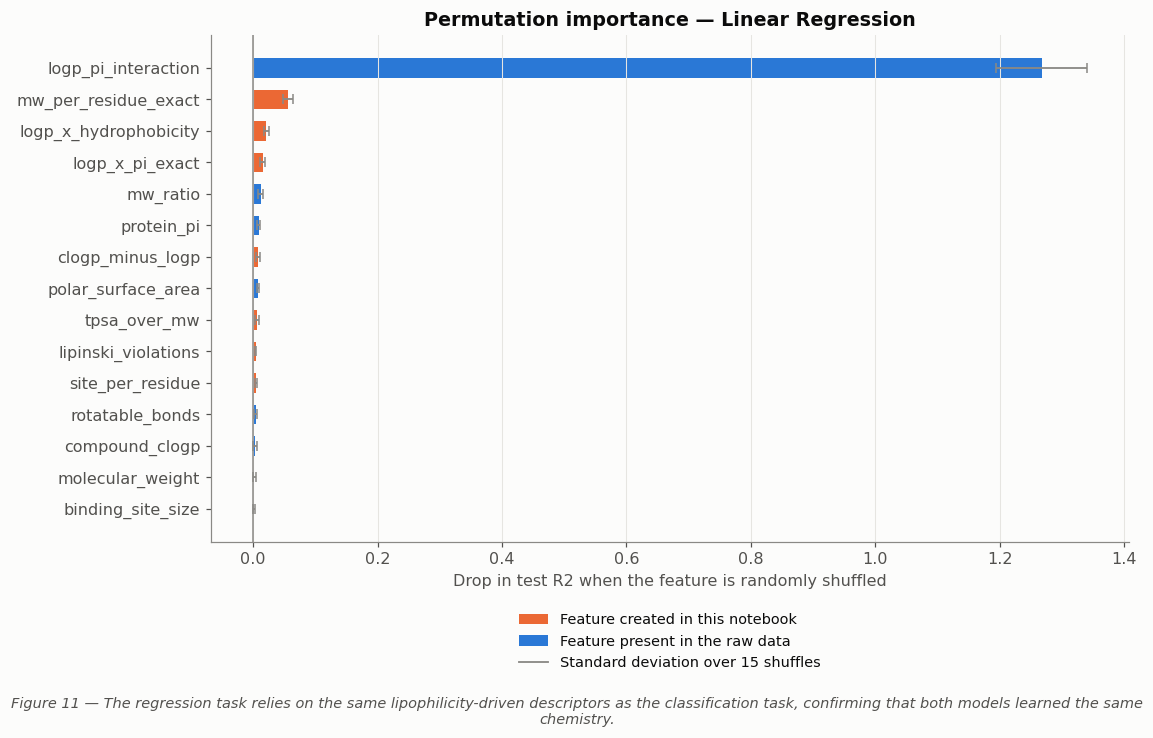

,feature,importance_mean,importance_std
0,logp_pi_interaction,1.26779,0.07319
1,mw_per_residue_exact,0.05566,0.00755
2,logp_x_hydrophobicity,0.02098,0.00391
3,logp_x_pi_exact,0.01506,0.00467
4,mw_ratio,0.01181,0.00410
5,protein_pi,0.00887,0.00255
6,clogp_minus_logp,0.00824,0.00352
7,polar_surface_area,0.00761,0.00182
8,tpsa_over_mw,0.00583,0.00311
9,lipinski_violations,0.00401,0.00105


In [36]:
# Permutation importance for the regression task
perm_reg = permutation_importance(best_reg_pipeline, X_test_reg, y_test_reg,
                                  n_repeats=15, random_state=RANDOM_STATE,
                                  scoring="r2", n_jobs=N_JOBS)

importance_reg = (pd.DataFrame({
    "feature": X_test_reg.columns,
    "importance_mean": perm_reg.importances_mean,
    "importance_std": perm_reg.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10.5, 6.4))
top_15 = importance_reg.head(15).sort_values("importance_mean")
is_engineered = top_15["feature"].isin(NEW_FEATURES + ["protein_id_encoded"])
ax.barh(top_15["feature"], top_15["importance_mean"], xerr=top_15["importance_std"], height=0.62,
        color=[CATEGORICAL[1] if e else CATEGORICAL[0] for e in is_engineered],
        error_kw=dict(ecolor=INK_MUTED, elinewidth=1.2, capsize=3))
ax.axvline(0, color=INK_MUTED, linewidth=1)
ax.set_xlabel("Drop in test R2 when the feature is randomly shuffled")
ax.set_title(f"Permutation importance — {BEST_REG_NAME}")
ax.grid(axis="y", visible=False)
legend_below(ax, [Patch(facecolor=CATEGORICAL[1]), Patch(facecolor=CATEGORICAL[0]),
                  Line2D([], [], color=INK_MUTED, linewidth=1.2)],
             ["Feature created in this notebook", "Feature present in the raw data",
              "Standard deviation over 15 shuffles"], ncol=1, y=-0.13)

finalize(fig, "The regression task relies on the same lipophilicity-driven descriptors as the "
              "classification task, confirming that both models learned the same chemistry.",
         "ml_11_regression_importance")

importance_reg.head(10).round(5)

---
## 12. Saving everything needed for deployment

A model file on its own is not deployable. Four things have to travel together, and all four are
written to `models/`:

1. **The fitted pipelines** — imputation, scaling and the estimator in one object.
2. **The label encoders** — production must map `PID_207` to the same integer as training did.
3. **The metadata** — the exact feature order, the chosen decision threshold, the measured
   performance and the library versions the artefacts were built with.
4. **The preprocessing code** — the feature-engineering function, exported verbatim so that
   training and inference can never drift apart.

In [37]:
# Save the two champion pipelines and all twenty benchmarked models
ALL_MODELS_DIR = MODELS_DIR / "all_models"
ALL_MODELS_DIR.mkdir(parents=True, exist_ok=True)


def slugify(name: str) -> str:
    return name.lower().replace(" ", "_").replace("-", "_")


saved = []

joblib.dump(final_clf_pipeline, MODELS_DIR / "best_classifier.joblib", compress=3)
saved.append(("best_classifier.joblib", f"{BEST_CLF_NAME} - predicts `active`"))

joblib.dump(best_reg_pipeline, MODELS_DIR / "best_regressor.joblib", compress=3)
saved.append(("best_regressor.joblib", f"{BEST_REG_NAME} - predicts `binding_affinity`"))

joblib.dump(label_encoders, MODELS_DIR / "label_encoders.joblib", compress=3)
saved.append(("label_encoders.joblib", "Fitted LabelEncoder for every categorical column"))

for name, pipeline in fitted_classifiers.items():
    joblib.dump(pipeline, ALL_MODELS_DIR / f"clf_{slugify(name)}.joblib", compress=3)
for name, pipeline in fitted_regressors.items():
    joblib.dump(pipeline, ALL_MODELS_DIR / f"reg_{slugify(name)}.joblib", compress=3)

total_mb = sum(f.stat().st_size for f in MODELS_DIR.rglob("*.joblib")) / 1024 ** 2
print(f"{len(list(MODELS_DIR.rglob('*.joblib')))} model files written "
      f"({total_mb:.1f} MB in total)")
pd.DataFrame(saved, columns=["file", "content"])

23 model files written (15.7 MB in total)


,file,content
0,best_classifier.joblib,Logistic Regression - predicts `active`
1,best_regressor.joblib,Linear Regression - predicts `binding_affinity`
2,label_encoders.joblib,Fitted LabelEncoder for every categorical column


In [38]:
# Metadata: everything a consumer of the model needs to know
# compound_id is optional at inference time: it is only carried through to label the output.
RAW_INPUT_COLUMNS = [c for c in raw.columns if c not in (TARGET_CLF, TARGET_REG, *ID_COLS)]

metadata = {
    "project": "Drug Discovery Virtual Screening",
    "created_at": pd.Timestamp.now().isoformat(timespec="seconds"),
    "random_state": RANDOM_STATE,
    "dataset": {
        "source_file": CSV_PATH.name,
        "rows": int(len(encoded)),
        "train_rows": int(len(train_idx)),
        "test_rows": int(len(test_idx)),
        "active_rate": float(y_clf.mean()),
        "activity_threshold_pki": 7.0,
    },
    "contract": {
        "required_raw_columns": RAW_INPUT_COLUMNS,
        "dropped_columns": ID_COLS,
        "categorical_columns": CATEGORICAL_COLS,
        "engineered_features": NEW_FEATURES,
        "model_feature_order": list(X_clf.columns),
        "unknown_category_code": -1,
    },
    "classification": {
        "best_model": BEST_CLF_NAME,
        "tuned": bool(USE_TUNED),
        "best_params": {k.replace("model__", ""): (v.item() if hasattr(v, "item") else v)
                        for k, v in search.best_params_.items()},
        "decision_threshold": float(FINAL_THRESHOLD),
        "test_roc_auc": float(roc_auc_score(y_test_clf, final_clf_proba)),
        "test_average_precision": float(average_precision_score(y_test_clf, final_clf_proba)),
        "test_f1_at_threshold": float(f1_score(y_test_clf, y_pred_final)),
        "test_mcc_at_threshold": float(matthews_corrcoef(y_test_clf, y_pred_final)),
    },
    "regression": {
        "best_model": BEST_REG_NAME,
        "test_rmse": float(np.sqrt(mean_squared_error(y_test_reg, y_pred_best))),
        "test_mae": float(mean_absolute_error(y_test_reg, y_pred_best)),
        "test_r2": float(r2_score(y_test_reg, y_pred_best)),
    },
    "leakage_rules": [
        "`binding_affinity` must never be a feature of the classifier "
        "(`active` is exactly `binding_affinity >= 7.0`).",
        "`active` must never be a feature of the regressor.",
        "`compound_id` is a unique key and is always dropped.",
    ],
    "library_versions": {
        "python": platform.python_version(),
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "joblib": joblib.__version__,
        # Needed by the boosted models in all_models/, even though the two champions do not use them.
        "xgboost": xgboost.__version__,
        "lightgbm": lightgbm.__version__,
    },
}

with open(MODELS_DIR / "model_metadata.json", "w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2)

# A pinned environment, so a deployer does not have to reverse-engineer one from the metadata.
requirements = "\n".join([
    "# Environment the artefacts in this folder were built with.",
    "# scikit-learn is pinned exactly: unpickling a model across a different version emits",
    "# InconsistentVersionWarning and may change behaviour silently.",
    f"python_requires>={platform.python_version_tuple()[0]}.{platform.python_version_tuple()[1]}",
    f"scikit-learn=={sklearn.__version__}",
    f"pandas=={pd.__version__}",
    f"numpy=={np.__version__}",
    f"joblib=={joblib.__version__}",
    f"xgboost=={xgboost.__version__}      # only needed for all_models/*xgboost*",
    f"lightgbm=={lightgbm.__version__}     # only needed for all_models/*lightgbm*",
    "",
])
(MODELS_DIR / "requirements.txt").write_text(requirements, encoding="utf-8")

print(json.dumps({k: v for k, v in metadata.items()
                  if k in ("classification", "regression", "library_versions")}, indent=2))
print(f"\nPinned environment written to {MODELS_DIR / 'requirements.txt'}")

{
  "classification": {
    "best_model": "Logistic Regression",
    "tuned": true,
    "best_params": {
      "solver": "lbfgs",
      "penalty": "l2",
      "C": 0.5
    },
    "decision_threshold": 0.4649999999999999,
    "test_roc_auc": 0.9578075244722255,
    "test_average_precision": 0.9264807840927585,
    "test_f1_at_threshold": 0.8122270742358078,
    "test_mcc_at_threshold": 0.7404865661302004
  },
  "regression": {
    "best_model": "Linear Regression",
    "test_rmse": 0.73922032659109,
    "test_mae": 0.3370437639012734,
    "test_r2": 0.6155316080979181
  },
  "library_versions": {
    "python": "3.12.4",
    "scikit_learn": "1.3.2",
    "pandas": "2.2.3",
    "numpy": "1.26.4",
    "joblib": "1.4.2",
    "xgboost": "3.0.1",
    "lightgbm": "4.6.0"
  }
}

Pinned environment written to C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\models\requirements.txt


In [39]:
# Export the preprocessing code itself, straight from this notebook
import inspect

# Emit the bounds as an exact Python literal. A `json.dumps(...).replace("null", "None")` would
# corrupt any future key or string value that happened to contain the substring "null".
BOUNDS_LITERAL = "{\n" + "".join(
    f"    {column!r}: ({low!r}, {high!r}),\n" for column, (low, high) in PHYSICAL_BOUNDS.items()
) + "}"

PREDICT_MODULE = f'''"""Inference utilities for the Drug Discovery Virtual Screening models.

Generated automatically by `notebook/02_machine_learning_models.ipynb`.
The preprocessing functions below are the EXACT source used during training, so training and
inference cannot drift apart.

Usage
-----
    from predict import ScreeningModel

    model = ScreeningModel()                       # loads everything from this folder
    result = model.predict(raw_dataframe)          # raw columns in, predictions out

Command line
------------
    python predict.py path/to/compounds.csv predictions.csv
"""
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import sklearn
from sklearn.preprocessing import LabelEncoder

ARTEFACT_DIR = Path(__file__).resolve().parent

PHYSICAL_BOUNDS = {BOUNDS_LITERAL}


{inspect.getsource(clip_to_physical_bounds)}

{inspect.getsource(exceeds)}

{inspect.getsource(engineer_features)}

{inspect.getsource(safe_label_transform)}

class ScreeningModel:
    """Loads the saved artefacts and turns raw compound/protein rows into predictions."""

    OUTPUT_COLUMNS = ["activity_probability", "predicted_active", "predicted_binding_affinity"]

    def __init__(self, artefact_dir: Path | str = ARTEFACT_DIR, check_versions: bool = True):
        self.dir = Path(artefact_dir)
        with open(self.dir / "model_metadata.json", encoding="utf-8") as fh:
            self.metadata = json.load(fh)
        self.classifier = joblib.load(self.dir / "best_classifier.joblib")
        self.regressor = joblib.load(self.dir / "best_regressor.joblib")
        self.label_encoders = joblib.load(self.dir / "label_encoders.joblib")
        self.feature_order = self.metadata["contract"]["model_feature_order"]
        self.threshold = self.metadata["classification"]["decision_threshold"]
        if check_versions:
            self._check_sklearn_version()

    def _check_sklearn_version(self) -> None:
        """Warn loudly when the runtime differs from the version the pickles were built with."""
        built_with = self.metadata.get("library_versions", {{}}).get("scikit_learn")
        if built_with and built_with != sklearn.__version__:
            warnings.warn(
                f"These artefacts were built with scikit-learn {{built_with}} but scikit-learn "
                f"{{sklearn.__version__}} is installed. Unpickling across versions can change "
                f"behaviour silently. See requirements.txt in this folder.",
                RuntimeWarning, stacklevel=3)

    def build_features(self, frame: pd.DataFrame) -> pd.DataFrame:
        """Apply exactly the training-time preprocessing to a raw table."""
        missing = [c for c in self.metadata["contract"]["required_raw_columns"]
                   if c not in frame.columns]
        if missing:
            raise ValueError(f"Missing required raw columns: {{missing}}")

        out = clip_to_physical_bounds(frame)
        out = engineer_features(out)
        for column, encoder in self.label_encoders.items():
            out[f"{{column}}_encoded"] = safe_label_transform(encoder, out[column])
        return out[self.feature_order].astype(float)

    def predict(self, frame: pd.DataFrame) -> pd.DataFrame:
        """Return activity probability, activity call and predicted binding affinity."""
        if len(frame) == 0:                       # an empty batch is a normal pipeline input
            return pd.DataFrame(columns=self.OUTPUT_COLUMNS, index=frame.index)

        features = self.build_features(frame)
        probability = self.classifier.predict_proba(features)[:, 1]
        affinity = self.regressor.predict(features)
        result = pd.DataFrame({{
            "activity_probability": probability,
            "predicted_active": (probability >= self.threshold).astype(int),
            "predicted_binding_affinity": affinity,
        }}, index=frame.index)
        for column in ("compound_id", "protein_id"):
            if column in frame.columns:
                result.insert(0, column, frame[column].values)
        return result


def main(argv: list[str]) -> int:
    if len(argv) < 2:
        print(__doc__)
        return 1
    source = Path(argv[1])
    destination = Path(argv[2]) if len(argv) > 2 else source.with_name(source.stem + "_scored.csv")
    model = ScreeningModel()
    predictions = model.predict(pd.read_csv(source))
    predictions.to_csv(destination, index=False)
    print(f"Wrote {{len(predictions):,}} predictions to {{destination}}")
    return 0


if __name__ == "__main__":
    import sys
    raise SystemExit(main(sys.argv))
'''

(MODELS_DIR / "predict.py").write_text(PREDICT_MODULE, encoding="utf-8")
print(f"Wrote {MODELS_DIR / 'predict.py'} "
      f"({len(PREDICT_MODULE.splitlines())} lines, preprocessing source copied verbatim)")

Wrote C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\models\predict.py (188 lines, preprocessing source copied verbatim)


In [40]:
# A README so the folder explains itself
required_columns_md = ", ".join("`" + c + "`" for c in RAW_INPUT_COLUMNS)
leakage_rules_md = "\n".join("- " + rule for rule in metadata["leakage_rules"])

README = f"""# Saved models — Drug Discovery Virtual Screening

Generated by `notebook/02_machine_learning_models.ipynb` on
{metadata['created_at']}.

## Files

| File | Content |
|---|---|
| `best_classifier.joblib` | {BEST_CLF_NAME} pipeline predicting `active` (imputer + scaler + model) |
| `best_regressor.joblib` | {BEST_REG_NAME} pipeline predicting `binding_affinity` |
| `label_encoders.joblib` | Fitted `LabelEncoder` for `protein_id` |
| `model_metadata.json` | Feature order, decision threshold, metrics, library versions |
| `requirements.txt` | The exact environment the artefacts were built with |
| `predict.py` | Self-contained inference module (also a command-line tool) |
| `all_models/` | All 10 classifiers and all 10 regressors from the benchmark |

## Measured performance (held-out test set, {len(test_idx)} compounds)

| Task | Model | Metric | Value |
|---|---|---|---|
| Classification | {BEST_CLF_NAME} | ROC-AUC | {metadata['classification']['test_roc_auc']:.4f} |
| Classification | {BEST_CLF_NAME} | Average precision | {metadata['classification']['test_average_precision']:.4f} |
| Classification | {BEST_CLF_NAME} | F1 at threshold {FINAL_THRESHOLD:.2f} | {metadata['classification']['test_f1_at_threshold']:.4f} |
| Regression | {BEST_REG_NAME} | RMSE (pKi) | {metadata['regression']['test_rmse']:.4f} |
| Regression | {BEST_REG_NAME} | R-squared | {metadata['regression']['test_r2']:.4f} |

## Installation

```bash
pip install -r models/requirements.txt
```

`scikit-learn` is pinned exactly. Loading these pickles under a different version raises
`InconsistentVersionWarning` and can change behaviour silently, so `ScreeningModel` compares the
runtime version against `model_metadata.json` at load time and warns when they differ.
`xgboost` and `lightgbm` are needed only for the corresponding files in `all_models/`; the two
champion pipelines load without them.

## Usage

```python
import pandas as pd
import sys

sys.path.append("models")
from predict import ScreeningModel

model = ScreeningModel("models")
new_compounds = pd.read_csv("input/drug_discovery_virtual_screening.csv").head()
model.predict(new_compounds)
```

Or from a terminal:

```bash
python models/predict.py input/drug_discovery_virtual_screening.csv output/scored.csv
```

## Required input columns

{required_columns_md}

`compound_id` is optional and is only copied through to the output. Missing values are allowed —
the pipeline imputes them with the training medians. A `protein_id` that was never seen during
training is encoded as `-1` rather than raising an error.

## Non-negotiable rules

{leakage_rules_md}
"""

(MODELS_DIR / "README.md").write_text(README, encoding="utf-8")
print(f"Wrote {MODELS_DIR / 'README.md'}")

Wrote C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\Drug Discovery Virtual Screening\models\README.md


---
## 13. Deployment smoke test

The artefacts are now loaded back **from disk in a fresh object**, fed with raw rows exactly as a
production caller would supply them, and the result is compared against the in-memory predictions.
If the two disagree, something in the export is broken and the assertion below fails.

In [41]:
# Reload from disk and score raw rows
import importlib.util
import shutil
import sys

sys.dont_write_bytecode = True          # keep the deployment folder free of __pycache__
spec = importlib.util.spec_from_file_location("screening_predict", MODELS_DIR / "predict.py")
screening_predict = importlib.util.module_from_spec(spec)
spec.loader.exec_module(screening_predict)
shutil.rmtree(MODELS_DIR / "__pycache__", ignore_errors=True)

deployed = screening_predict.ScreeningModel(MODELS_DIR)

# Raw rows straight from the CSV - no preprocessing applied by the caller.
sample_raw = raw.iloc[test_idx[:8]].drop(columns=[TARGET_CLF, TARGET_REG])
predictions = deployed.predict(sample_raw)

check = predictions.copy()
check["true_active"] = raw.iloc[test_idx[:8]][TARGET_CLF].values
check["true_binding_affinity"] = raw.iloc[test_idx[:8]][TARGET_REG].values.round(3)
check.round(4)

,protein_id,compound_id,activity_probability,predicted_active,predicted_binding_affinity,true_active,true_binding_affinity
288,PID_288,CID_00288,0.0143,0,5.9372,0,5.541
1495,PID_442,CID_01495,0.9933,1,8.3522,1,8.443
1271,PID_319,CID_01271,0.0127,0,5.7353,0,5.564
1488,PID_366,CID_01488,0.0078,0,5.6631,0,5.873
528,PID_263,CID_00528,0.9798,1,7.9041,1,7.643
222,PID_421,CID_00222,0.5091,1,7.2948,0,6.874
998,PID_459,CID_00998,0.0838,0,6.7345,0,6.559
470,PID_241,CID_00470,0.9826,1,7.9210,1,8.354


In [42]:
# Assert that the deployed artefacts reproduce the notebook exactly
deployed_all = deployed.predict(raw.iloc[test_idx].drop(columns=[TARGET_CLF, TARGET_REG]))

proba_match = np.allclose(deployed_all["activity_probability"].values, final_clf_proba, atol=1e-9)
affinity_match = np.allclose(deployed_all["predicted_binding_affinity"].values, y_pred_best,
                             atol=1e-9)

print(f"Activity probabilities identical to the notebook : {proba_match}")
print(f"Affinity predictions identical to the notebook   : {affinity_match}")
assert proba_match and affinity_match, "The saved artefacts do not reproduce the notebook."

# the edge cases production will actually hit
unseen = sample_raw.copy()
unseen["protein_id"] = "PID_NEVER_SEEN"
print(f"Unseen protein            -> {len(deployed.predict(unseen))} rows scored, no error")

no_id = sample_raw.drop(columns=["compound_id"])
print(f"No compound_id column     -> {len(deployed.predict(no_id))} rows scored, no error")

shuffled = sample_raw[sample_raw.columns[::-1]]
print(f"Columns in reverse order  -> predictions identical: "
      f"{np.allclose(deployed.predict(shuffled)['activity_probability'], predictions['activity_probability'])}")

single = sample_raw.head(1)
print(f"Single-row frame          -> {len(deployed.predict(single))} row scored, no error")

empty = sample_raw.head(0)
print(f"Empty frame               -> {len(deployed.predict(empty))} rows returned, no error")

gappy = sample_raw.copy()
gappy.loc[gappy.index[0], "logp"] = np.nan
print(f"Row with a missing logp   -> probability "
      f"{deployed.predict(gappy)['activity_probability'].iloc[0]:.4f} (imputed, no error)")

print("\nSample predictions on an unseen protein:")
deployed.predict(unseen).head(3).round(4)

Activity probabilities identical to the notebook : True
Affinity predictions identical to the notebook   : True
Unseen protein            -> 8 rows scored, no error
No compound_id column     -> 8 rows scored, no error
Columns in reverse order  -> predictions identical: True
Single-row frame          -> 1 row scored, no error
Empty frame               -> 0 rows returned, no error
Row with a missing logp   -> probability 0.0217 (imputed, no error)

Sample predictions on an unseen protein:


,protein_id,compound_id,activity_probability,predicted_active,predicted_binding_affinity
288,PID_NEVER_SEEN,CID_00288,0.0163,0,5.9037
1495,PID_NEVER_SEEN,CID_01495,0.9948,1,8.2913
1271,PID_NEVER_SEEN,CID_01271,0.0148,0,5.6963


**The smoke test is the point.** It proves three separate things at once: the exported
preprocessing reproduces training exactly, the artefacts load in a fresh namespace without the
notebook, and an unseen protein degrades gracefully to code `-1` instead of raising. A model that
has not passed this test is not deployable, however good its ROC-AUC looks.

---
## 14. Results and conclusions

In [43]:
# Export the benchmark tables
clf_table.to_csv(OUTPUT_DIR / "ml_classification_results.csv")
reg_table.to_csv(OUTPUT_DIR / "ml_regression_results.csv")
importance_clf.to_csv(OUTPUT_DIR / "ml_classifier_feature_importance.csv", index=False)
importance_reg.to_csv(OUTPUT_DIR / "ml_regressor_feature_importance.csv", index=False)
scan.assign(surface="out_of_fold_train").to_csv(OUTPUT_DIR / "ml_threshold_scan.csv", index=False)
scan_test.assign(surface="held_out_test").to_csv(OUTPUT_DIR / "ml_threshold_scan_test.csv", index=False)
pd.DataFrame(FIGURE_INDEX).to_csv(OUTPUT_DIR / "ml_figure_index.csv", index=False)

summary = pd.DataFrame([
    ("Classification winner", BEST_CLF_NAME,
     f"ROC-AUC {metadata['classification']['test_roc_auc']:.4f}, "
     f"average precision {metadata['classification']['test_average_precision']:.4f}"),
    ("Regression winner", BEST_REG_NAME,
     f"RMSE {metadata['regression']['test_rmse']:.4f} pKi, "
     f"R2 {metadata['regression']['test_r2']:.4f}"),
    ("Decision threshold", f"{FINAL_THRESHOLD:.3f}", "Chosen by maximising F1 on out-of-fold training predictions"),
    ("Features used", str(len(X_clf.columns)),
     f"{len(raw.columns) - 4} raw + {len(NEW_FEATURES)} engineered + 1 label-encoded"),
    ("Models benchmarked", "20", "10 classifiers and 10 regressors, each inside a Pipeline"),
    ("Artefacts written", str(len(list(MODELS_DIR.rglob('*')))),
     f"in {MODELS_DIR.name}/ - pipelines, encoders, metadata, predict.py, README"),
], columns=["item", "value", "detail"])
summary

,item,value,detail
0,Classification winner,Logistic Regression,"ROC-AUC 0.9578, average precision 0.9265"
1,Regression winner,Linear Regression,"RMSE 0.7392 pKi, R2 0.6155"
2,Decision threshold,0.465,Chosen by maximising F1 on out-of-fold trainin...
3,Features used,27,13 raw + 13 engineered + 1 label-encoded
4,Models benchmarked,20,"10 classifiers and 10 regressors, each inside ..."
5,Artefacts written,28,"in models/ - pipelines, encoders, metadata, pr..."


### 14.2 What the benchmark showed

**1. The task has a hard ceiling, and it is mostly chemical rather than algorithmic.** The EDA found
that only `logp`, `protein_pi` and their interaction carry signal. Ten very different algorithms
therefore land in a narrow band, and about 70% of the classification errors sit within 0.3 pKi of
the 7.0 cut-off, where the label is genuinely ambiguous — no model can separate a compound at 6.98
from one at 7.02. The remaining ~30% of errors are *not* boundary cases, and they are the part
that better chemistry (fingerprints, docking scores) could still fix.

**2. The linear models won both tasks, and the ablation in section 7.7 says why.** Binding affinity
is driven by lipophilicity *multiplied by* the target's isoelectric point, and that product ships
in the raw data as `logp_pi_interaction`. Boosted trees must approximate a product with a
staircase of axis-aligned splits; a linear model handed the product directly represents it
exactly. Remove that one column and both models lose a large, unambiguous amount — remove the
thirteen features engineered in section 3 and almost nothing changes, because they duplicate a
signal the dataset already provides.

The honest lesson is therefore about **which feature carries the signal, not about who created
it**: one interaction term was worth more than every hyper-parameter in the search space and more
than the choice between ten algorithms. Feature engineering earns its place here through
robustness and explicitness, not through accuracy — and the only way to know that was to measure
it rather than assume it.

**3. Leakage was the single biggest risk.** The naive recipe suggested in the dataset description
(`X = df.drop(['active','compound_id'], axis=1)`) leaves `binding_affinity` in the feature matrix
and yields a perfect, worthless classifier. Both notebooks reject that construction and assert the
exclusion in code.

**4. Accuracy is the wrong headline.** Always predicting "inactive" already scores about 70%. The benchmark is
ranked on ROC-AUC and average precision, and Matthews correlation is reported because it only
improves when both classes are handled well.

**5. The regressor is the more useful product.** It returns a graded affinity that a chemistry
team can prioritise against its own budget, and any threshold — including a different one per
campaign — can be applied afterwards without retraining.

### 14.3 What would improve the models further

* **More chemistry, not more algorithms.** Molecular fingerprints (ECFP), three-dimensional
  descriptors or a docking score would add signal that no amount of tuning can extract from
  thirteen bulk descriptors.
* **Group-aware validation.** With about five compounds per protein, splitting by `protein_id`
  (`GroupKFold`) would give a more honest estimate of performance on an entirely new target.
* **Model the continuous target only.** Training the regressor and thresholding its output is
  often stronger than training a separate classifier, and it keeps the two outputs consistent by
  construction.
* **Quantified uncertainty.** Conformal prediction or a quantile regressor would attach an
  interval to each prediction, which is what a screening triage decision actually needs.

---

**Artefacts produced by this notebook**

* `models/best_classifier.joblib`, `models/best_regressor.joblib`, `models/label_encoders.joblib`
* `models/model_metadata.json`, `models/predict.py`, `models/README.md`
* `models/all_models/` — all twenty benchmarked pipelines
* `output/ml_*.csv` — benchmark tables, feature importance and the threshold scan
* `output/figures/ml_*.png` — every figure in this notebook